In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import logomaker
import os
import scipy.stats
import matplotlib.gridspec as gridspec
import glob
import sys
import numpy as np
import collections

In [2]:
sys.path.append('/data/gralak/meSMiLEseq_github/meSMiLEseq')
import utils

In [3]:
#Defining dependencies and stuff needed for the script to running properly
def _dictionary():
    return {
        'exp1': 'SmSAG01',
        'exp01': 'SmSAG01',
        'exp2': 'SmSAG02',
        'exp02': 'SmSAG02',
        'exp3': 'SmSAG03',
        'exp03': 'SmSAG03',
        'exp4': 'SmSAG04',
        'exp04': 'SmSAG04',
        'exp5': 'SmSAG05',
        'exp05': 'SmSAG05',
        'exp6': 'SmSAG06',
        'exp06': 'SmSAG06',
        'exp7': 'SmSAG07',
        'exp07': 'SmSAG07',
        'exp8': 'SmSAG08',
        'exp08': 'SmSAG08',
        'exp9': 'SmSAG09',
        'exp09': 'SmSAG09',
        'exp10': 'SmSAG10',
        'exp11': 'SmSAG11',
        'exp12': 'SmSAG12',
        'exp13': 'SmSAG13',
        'exp14': 'SmSAG14',
        'exp15': 'SmSAG15',
        'exp16': 'SmSAG16',
        'exp17': 'SmSAG17',
        'exp18': 'SmSAG18',
        'exp19': 'SmSAG19',
        'exp20': 'SmSAG20',
        'exp21': 'SmSAG21',
        'exp22': 'SmSAG22',
        'exp23': 'SmSAG23',
        'exp24': 'SmSAG24',
        '1': 'BC1',
        '2': 'BC2',
        '3': 'BC3',
        '4': 'BC4',
        '5': 'BC5',
        '6': 'BC6',
        '7': 'BC7',
        '8': 'BC8',
        '9': 'BC9',
        '10': 'BC10',
        '11': 'BC11',
        '12': 'BC12',
        'input1_fwd/rev': '20220315_input',
        'input2_fwd/rev': '20220915_input',
        'input3_fwd/rev': '20230228_input',
        'input4_fwd/rev': '20230503_input'
}
metadata_dict = _dictionary()

def assign_mBC(input_spec):
    """function accepts a character string as input_spec, so input1_fwd/rev etc. 
    Returns as first element methylated Barcode, as second the unmethylated counterpart, and the path to the data."""
    if input_spec == 'input1_fwd/rev':
        methylated_BC = "AGTA"
        unmethylated_BC = "GAGT"
        input_path = '/home/gralak/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20220315_input/00_read_in_data/output/'
    elif input_spec == 'input2_fwd/rev':
        methylated_BC = "AGTA"
        unmethylated_BC = "GAAT"
        input_path = '/home/gralak/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20220915_input/00_read_in_data/output/'
    elif input_spec == 'input3_fwd/rev':
        methylated_BC = "AGTA"
        unmethylated_BC = "GAAT"
        input_path = '/home/gralak/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230228_input/00_read_in_data/output/'
    elif input_spec == 'input4_fwd/rev':
        methylated_BC = "AGTA"
        unmethylated_BC = "GAAT"
        input_path = '/home/gralak/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230503_input/00_read_in_data/output/'
    
    return (methylated_BC, unmethylated_BC, input_path)

In [4]:
metadata = pd.read_csv('/data/gralak/meSMiLEseq_github/meSMiLEseq/metadata.csv')
latest_curation = pd.read_csv('/data/gralak/meSMiLEseq_github/meSMiLEseq/TF_with_motifs_latest_curation.csv')
TFs = os.listdir('/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication')
filtered_TFs = [tf for tf in TFs if not tf.endswith('.csv')]

In [5]:
kl_threshold = 0.1
js_threshold = 0.01

In [ ]:
filtered_TFs = ['ZNF793_FL',#
'ZNF8_FL',#
 'ZNF777_FL',#
 'ZNF131_FL',#
 'ZNF468_FL',#
 'USF3_DBD',#
 'MSANTD1_FL',#
 'ZKSCAN4_DBD',#
 'ZNF831_DBD',#
 'CAMTA1_DBD',#
 'ZNF133_FL',#
 'ZNF263_FL',#
 'ZNF891_FL',#
 'ZNF680_FL',#
 'ZNF614_FL',#
 'TIGD4_FL',#
 'PRDM5_DBD',#
 'PRDM10_DBD',#
 'ZBED4_DBD',#
 'ZNF716_FL',#
 'ZNF18_FL',#
 'POU5F1_FL',#
 'ZXDB_DBD',#
 'TPRX1_DBD',#
 'ZNF648_DBD',#
 'TIGD5_DBD',#
 'MBD1_DBD',#
 'ZNF695_FL',#
 'ZFP14_FL',#
 'PRDM13_DBD',#
 'ZNF503_DBD',#
 'ZNF75D_FL',#
 'TTF1_DBD',#
 'ZNF445_FL',#
 'ZFP1_FL',#
 'ZNF367_FL',#
 'RFX5_FL',#
 'ZNF395_DBD',
 'ZNF23_FL']

In [8]:
TF = 'ZNF23_FL'#


In [617]:
for protein in filtered_TFs:
    TF = protein
    filtered_TFs.remove(protein)
    print(f'{len(filtered_TFs)} to go, courage!!! <3')
    break

print(TF)

ZNF23_FL


In [254]:
add_to_consensus_seqs = 'AGTGCTCGC'

In [9]:
data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'

joint_matrices_path = os.path.join(data_path, 'joint/matrices/')    
sep_matrices_path = os.path.join(data_path, 'separated/matrices/')


files_sep = os.listdir(sep_matrices_path)
meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]

files_joint = os.listdir(joint_matrices_path)
dGGs = [f for f in files_joint if f.endswith('bindingmode_1.csv')]

dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)


##############
#Getting all the paths  for the raw data, looks ugly and it is
SMSAGxx = latest_curation[latest_curation.TF == TF].exp.values[0]
BC = metadata[
    (metadata['TF'] == TF) & 
    (metadata['experiment'].str.replace('exp', '').astype(int) == int(SMSAGxx.replace('exp', '')))].Chip_pos.values[0]
put_in = metadata[
    (metadata['TF'] == TF) & 
    (metadata['experiment'].str.replace('exp', '').astype(int) == int(SMSAGxx.replace('exp', '')))].input_library.values[0]

SMSAGxx = metadata_dict[SMSAGxx]


mBC, umBC, input_path = assign_mBC(put_in)

input_path = os.path.join(input_path, f'BC{BC}_contamination_filtered.csv')
########
#load the stuff
BC_in = pd.read_csv(input_path)

df_in = pd.read_csv(
    f'~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/{SMSAGxx}/00_read_in_data/output/BC{BC}_contamination_filtered.csv'
)

in_m = BC_in[BC_in['methl'] == mBC].reset_index(drop=True)
in_nm = BC_in[BC_in['methl'] == umBC].reset_index(drop=True)

df_m = df_in[df_in['methl'] == mBC].reset_index(drop=True)
df_nm = df_in[df_in['methl'] == umBC].reset_index(drop=True)

In [10]:
#############################
# Now let the fun begin
# Strategy: take ddG, make probability matrix. Take background probability, calculate per position KL divergence
# (how much the logo diverges from the background). Take first and last position of logo and crop for consensus.
# Then, identify CG positions in both consensus sequences, also calculate the Jensen Shannon divergence between them
# to identify positions in which the sequences diverge from each other (threshold 0.01). To circumvent problem with
# too sparse data/too long consensus sequences: If consensus is longer than 11, split it into two words with 8 nt.
# Mutate each identified position and calculate the probability of the word in the raw data. Print the words and 
# occurrencies in a human readable form.

#Convert ProBOund logos into probabilites
psam_m = utils.ddG_to_psam(dGGm)
psam_um = utils.ddG_to_psam(dGGum)

ppm_m = utils.pfm_to_ppm(psam_m)
ppm_um = utils.pfm_to_ppm(psam_um)

#Estimate nucleotide distribution in background
nuc_m = utils.estimate_nucleotide_distribution(in_m, seq_col='random24')
nuc_um = utils.estimate_nucleotide_distribution(in_nm, seq_col='random24')

#Calculate KL diveregences between ppm and background and crop consensus
c_kl_m = utils.compute_kl_divergence(ppm_m, nuc_m)
c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um)  

cropped_m = utils.crop_consensus(c_kl_m, threshold=kl_threshold)
cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)

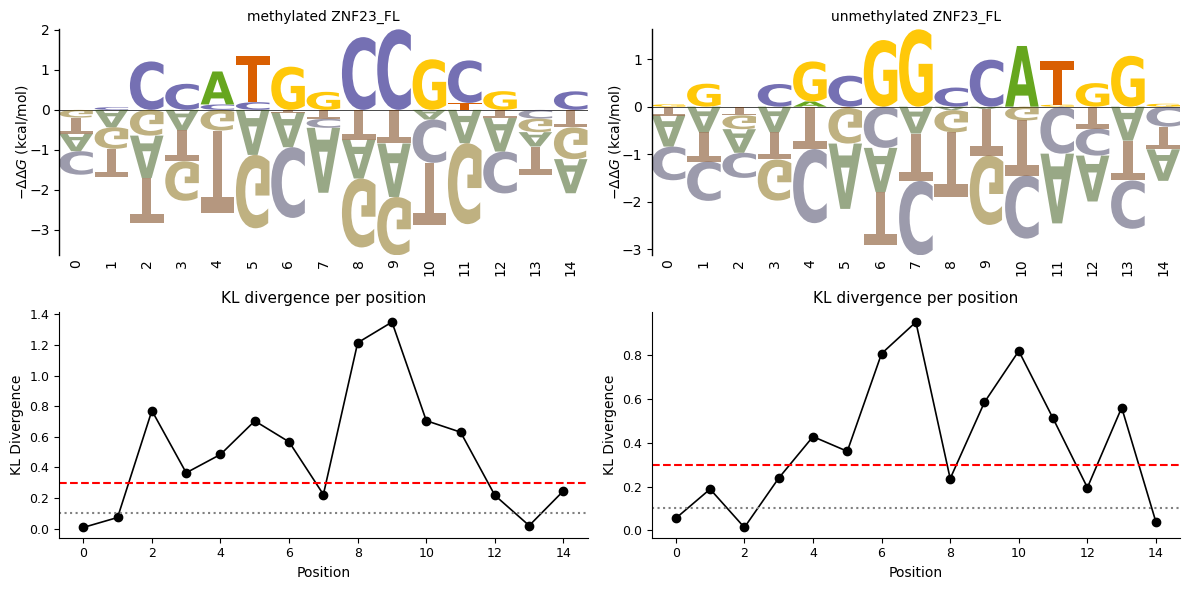

In [11]:
#Sanity check plot kl div and logos
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax_dGGm = fig.add_subplot(gs[0, 0])
ax_KL_m = fig.add_subplot(gs[1, 0])
ax_dGGum = fig.add_subplot(gs[0, 1])
ax_KL_um = fig.add_subplot(gs[1, 1])

utils.make_logo(dGGm, ax=ax_dGGm, title=f'methylated {TF}')
utils.make_logo(dGGum, ax=ax_dGGum, title=f'unmethylated {TF}')
utils.plot_kl_divergence(c_kl_m, ax=ax_KL_m)
utils.plot_kl_divergence(c_kl_um, ax=ax_KL_um)
plt.tight_layout()
plt.show()

In [516]:
# Block to take rev complement directly
dGGum = utils.rev_complement(dGGum, extended_alphabet=False)
ppm_um = utils.rev_complement(ppm_um, extended_alphabet=False)
c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um) 
cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)

In [12]:
# Block to take rev complement directly
dGGm = utils.rev_complement(dGGm, extended_alphabet=False)
ppm_m = utils.rev_complement(ppm_m, extended_alphabet=False)
c_kl_m = utils.compute_kl_divergence(ppm_m, nuc_m) 
cropped_m = utils.crop_consensus(c_kl_m, threshold=kl_threshold)

In [13]:
# Divergent consensus seq
check_m = utils.ddg_to_consensus(dGGm.loc[cropped_m.index[0]:cropped_m.index[-1],:])
check_um = utils.ddg_to_consensus(dGGum.loc[cropped_um.index[0]:cropped_um.index[-1],:])

print(check_m)
print(check_um)

adj_idx_m = list(range(cropped_m.index[0], cropped_m.index[-1] + 1))
adj_idx_um = list(range(cropped_um.index[0], cropped_um.index[-1] + 1))

GGCGCGGCCATGG
GTCGCGGCCATGG


In [417]:
#NOT SURE I NEED THIS HERE!
# compare and align if needed, take rev complement
if len(check_m) == len(check_um):
    min_val = len(utils.where_difference(check_m, check_um))
    result = len(utils.where_difference(check_m, utils.rev_complement_seq(check_um)))
    if result < min_val:
        print('Using rev complement, based on cropped sequence')
        dGGum = utils.rev_complement(dGGum, extended_alphabet=False)
        ppm_um = utils.rev_complement(ppm_um, extended_alphabet=False)
        c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um) 
        cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)
        check_um = utils.ddg_to_consensus(dGGum.loc[cropped_um.index[0]:cropped_um.index[-1],:])
        adj_idx_um = list(range(cropped_um.index[0], cropped_um.index[-1] + 1))

print(check_m)
print(check_um)

Using rev complement, based on cropped sequence
GGTGTGAAC
GGTGTGAAC


In [215]:
if len(check_m) != len(check_um):
    # compare and align if needed, take rev complement
    full_m = utils.ddg_to_consensus(dGGm)
    full_um = utils.ddg_to_consensus(dGGum)
    min_val = len(utils.where_difference(full_m, full_um))
    result = len(utils.where_difference(full_m, utils.rev_complement_seq(full_um)))
    if result < min_val:
        print('Using rev complement, based on length')
        dGGum = utils.rev_complement(dGGum, extended_alphabet=False)
        ppm_um = utils.rev_complement(ppm_um, extended_alphabet=False)
        c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um) 
        cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)
        check_um = utils.ddg_to_consensus(dGGum.loc[cropped_um.index[0]:cropped_um.index[-1],:])
        adj_idx_um = list(range(cropped_um.index[0], cropped_um.index[-1] + 1))

    print(check_m)
    print(check_um)

GGCTAGATG
GCTA


In [594]:
# If there is just a raster problem, align the sequences
if len(check_m) != len(check_um):
    if len(check_m) >= len(check_um):
        
        long = check_m
        short = check_um
        idx_short = adj_idx_um
        matrix_short = dGGum
    else:
      
        long = check_um
        short = check_m
        idx_short = adj_idx_m
        matrix_short = dGGm

    delta = len(long) - len(short)

    min_hamming = float('inf')
    best_offset = 0

    for i in range(delta + 1):
        dist = utils.hamming_distance(long[i:len(long) - delta + i], short)
        
        if dist < min_hamming:
            min_hamming = dist
            best_offset = i

    front_ = best_offset
    back_ = len(long) - (len(short) + best_offset)

    start = min(idx_short)
    end = max(idx_short)

    left_extension = list(range(start - front_, start))
    right_extension = list(range(end + 1, end + 1 + back_))



    if len(check_m) >= len(check_um):
        extended_list = sorted(left_extension + adj_idx_um + right_extension)
        adj_idx_um = extended_list
    else:
        extended_list = sorted(left_extension + adj_idx_m + right_extension)
        adj_idx_m = extended_list

    # adjust adj in case out of bound
    if long == check_m:
       
        while True:
            try:
                dGGum.loc[adj_idx_um,:]
                break
            except KeyError:
                print('dGGum is out of bound')
                if adj_idx_um[0] < 0:
                    # how much to clip
                    remove = len([x for x in adj_idx_um if x < 0])

                    adj_idx_um = [x for x in adj_idx_um if x >= 0]
                    adj_idx_m = adj_idx_m[remove:]
                    continue
                elif adj_idx_um[-1] >= len(dGGum):
                    # how much to clip
                    remove = len([x for x in adj_idx_um if x >= len(dGGum)])
                    adj_idx_um = [x for x in adj_idx_um if x < len(dGGum)]

                    len_long = len(adj_idx_m)
                    adj_idx_m = adj_idx_m[:len_long - remove]
                    continue
    else:
       
        while True:
            try:
                dGGm.loc[adj_idx_m,:]
                break
            except KeyError:
                print('dGGm is out of bound')
                if adj_idx_m[0] < 0:
                    
                    # how much to clip
                    remove = len([x for x in adj_idx_m if x < 0])

                    adj_idx_m = [x for x in adj_idx_m if x >= 0]
                    adj_idx_um = adj_idx_um[remove:]
                    continue
                elif adj_idx_m[-1] >= len(dGGm):
                    
                    # how much to clip
                    remove = len([x for x in adj_idx_m if x >= len(dGGm)])
                    adj_idx_m = [x for x in adj_idx_m if x < len(dGGm)]

                    
                    len_long = len(adj_idx_um)
                    adj_idx_um = adj_idx_um[:len_long - remove]
                    
                    continue

    check_m = utils.ddg_to_consensus(dGGm.loc[adj_idx_m,:])
    check_um = utils.ddg_to_consensus(dGGum.loc[adj_idx_um,:])

    print(check_m)
    print(check_um)

dGGum is out of bound
CGTTGCCATGG
CGTTGCCATGG


In [560]:
# not sure i need this block
if len(check_m) != len(check_um):       
    # IF NOT ALIGNED, try

    adj_idx_m, adj_idx_um = utils.optimal_consensus_alignment(
                            cropped_m, cropped_um,
                            dGGm, dGGum,
                            max_shift=2
                            )

    check_m = utils.ddg_to_consensus(dGGm.loc[adj_idx_m,:])
    check_um = utils.ddg_to_consensus(dGGum.loc[adj_idx_um,:])

    print(check_m)
    print(check_um)

In [14]:
cons_m = check_m
cons_um = check_um

{2, 4}
GGCGCGGCCATGG
GTCGCGGCCATGG
[2, 4, 5, 9]


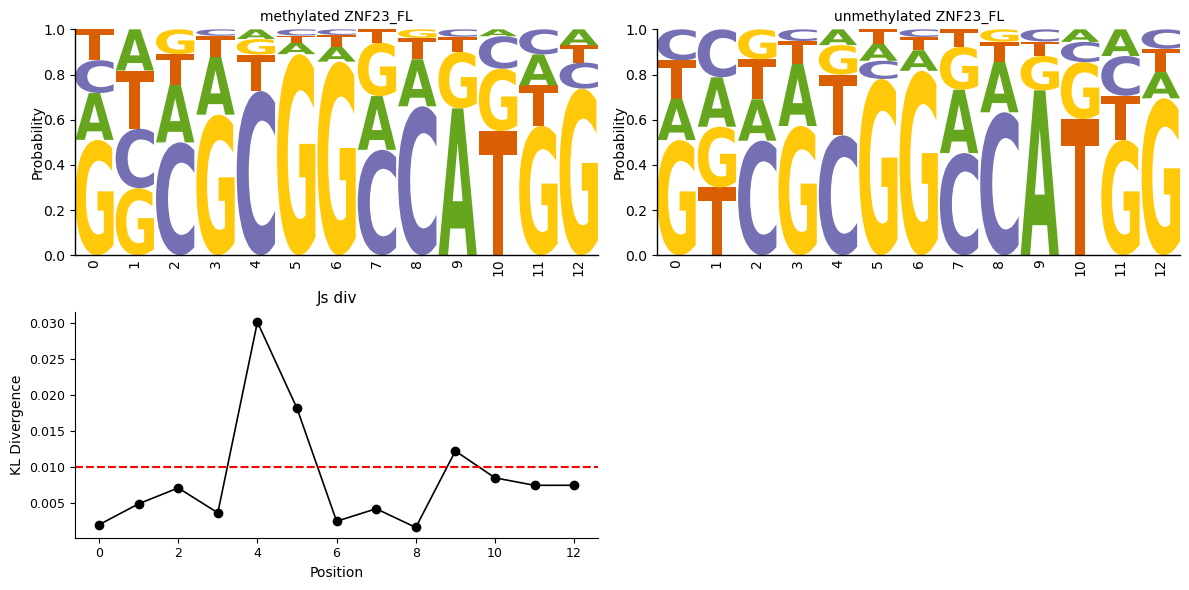

In [16]:
# Identify where CGs are in both consensus sequences, then calculate jenson shannon div
CGm = utils.where_CG(cons_m)
CGum = utils.where_CG(cons_um)

CG = set(CGm + CGum)



# Identify differences in KL filtered consensus based on jensen shannon divergence (threshold 0.01)
consensus_ppm_m = ppm_m.loc[adj_idx_m,:].reset_index(drop=True)
consensus_ppm_um = ppm_um.loc[adj_idx_um,:].reset_index(drop=True)
c_js = utils.jensen_shannon_divergence(consensus_ppm_m, consensus_ppm_um)

js_div = list(c_js[c_js >= js_threshold].index) # Here is another possibility to plot the difference between the plots.


differences = utils.resolve_cg_js_div(CG=CG, js_div=js_div)

print(CG)
print(cons_m)
print(cons_um)
print(differences)

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax_crop_m = fig.add_subplot(gs[0, 0])
ax_js_m = fig.add_subplot(gs[1, 0])
ax_crop_um = fig.add_subplot(gs[0, 1])
#ax_KL_um = fig.add_subplot(gs[1, 1])

utils.ppm_logo(consensus_ppm_m, ax=ax_crop_m, title=f'methylated {TF}')
utils.ppm_logo(consensus_ppm_um, ax=ax_crop_um, title=f'unmethylated {TF}')
utils.plot_kl_divergence(c_js, ax=ax_js_m, threshold_minor=js_threshold, threshold_major=js_threshold, title='Js div')

plt.tight_layout()
plt.show()

In [17]:
# look for the two consensus sequences, if their hamming distance is greater than 1, append both consensus sequences to list
diff = utils.hamming_distance(cons_m, cons_um)
if diff > 1:
    consensus_seqs = [cons_m, cons_um]
else:
    consensus_seqs = [cons_m]



# What if there are secondary CGs that aer not picked up by consensus?
check_secondary_CG_sequences_m = utils.find_stabilizing_CG(dGGm.loc[adj_idx_m,:].reset_index(drop=True))
check_secondary_CG_sequences_um = utils.find_stabilizing_CG(dGGum.loc[adj_idx_um,:].reset_index(drop=True))

for id in check_secondary_CG_sequences_m:
    if not cons_m[id] == 'C' and not cons_m[id+1] == 'G':
        sec_cons_m = list(cons_m)
        sec_cons_m[id] = 'C'
        sec_cons_m[id+1] = 'G'
        sec_cons_m = ''.join(sec_cons_m)
        consensus_seqs.append(sec_cons_m)

for id in check_secondary_CG_sequences_um:
    if not cons_um[id] == 'C' and not cons_um[id+1] == 'G':
        sec_cons_um = list(cons_um)
        sec_cons_um[id] = 'C'
        sec_cons_um[id+1] = 'G'
        sec_cons_um = ''.join(sec_cons_um)
        consensus_seqs.append(sec_cons_um)

print(consensus_seqs)

['GGCGCGGCCATGG']


In [360]:
add_to_consensus_seqs = 'AGTAAGACGGATATG'

In [361]:
if len(add_to_consensus_seqs) > 0:
    consensus_seqs.append(add_to_consensus_seqs)

print(consensus_seqs)

['AGTAAGATTGATATG', 'AGTAAGACGGATATG']


In [257]:
differences.append(7)

In [ ]:
# And now search for the words in the raw data
printable_m = []
printable_um = []
for sequence in consensus_seqs:
    for posi in differences:
        if len(sequence) > 10:
            k = 8
            _k = k//2
            k_ = k - _k
            if posi - _k < 0:
                frag = sequence[0:k]
                p = posi
            elif posi + k_ >= len(sequence):
                frag = sequence[-k:]
                #last_index = len(sequence)
                p = posi - len(sequence) + k
            else:
                frag = sequence[posi-_k:posi+k_]
                p = _k
        else:
            k = len(sequence)
            frag = sequence
            p = posi

        search_for = []
        search_for.extend(utils.single_point_mut_seq(frag, p))
        search_for.append(frag)

        search_for_rev = [utils.rev_complement_seq(i) for i in search_for]
        
        search_for_rev.extend(search_for)

        pattern = '|'.join(search_for_rev)
        consens_m = df_m[df_m['random24'].str.contains(pattern, regex=True)]
        consens_um = df_nm[df_nm['random24'].str.contains(pattern, regex=True)]

        consens_kmer_m = utils.kmer_counting(consens_m, kmer=k,one_df=True, mbc = [mBC, umBC])
        consens_kmer_um = utils.kmer_counting(consens_um, kmer=k,one_df=True, mbc = [mBC, umBC])

    ##################
        distrib_m = {}
        wrd_n = 0
        for word in search_for:
            freq = consens_kmer_m[consens_kmer_m['kmer'].str.contains(word, regex=True)]['count'].sum()
            freq += consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
            wrd_n += freq

            distrib_m[word] = freq

        distrib_m['sum'] = wrd_n

        printable_m.append(f'methylated {sequence}, nucleotide {posi+1}:')
        for word in search_for:
            fraction = distrib_m[word] / distrib_m['sum']
            printable_m.append(f"{word}: {fraction:.3f}, abs occurrences {distrib_m[word]}")

        

    ###################
        distrib_um = {}
        wrd_n = 0
        for word in search_for:
            freq = consens_kmer_um[consens_kmer_um['kmer'].str.contains(word, regex=True)]['count'].sum()
            freq += consens_kmer_um[consens_kmer_um['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
            wrd_n += freq
            distrib_um[word] = freq

        distrib_um['sum'] = wrd_n

        printable_um.append(f'unmethylated {sequence}, nucleotide {posi+1}:')
        for word in search_for:
            fraction = distrib_um[word] / distrib_um['sum']
            printable_um.append(f"{word}: {fraction:.3f}, abs occurrences {distrib_um[word]}")

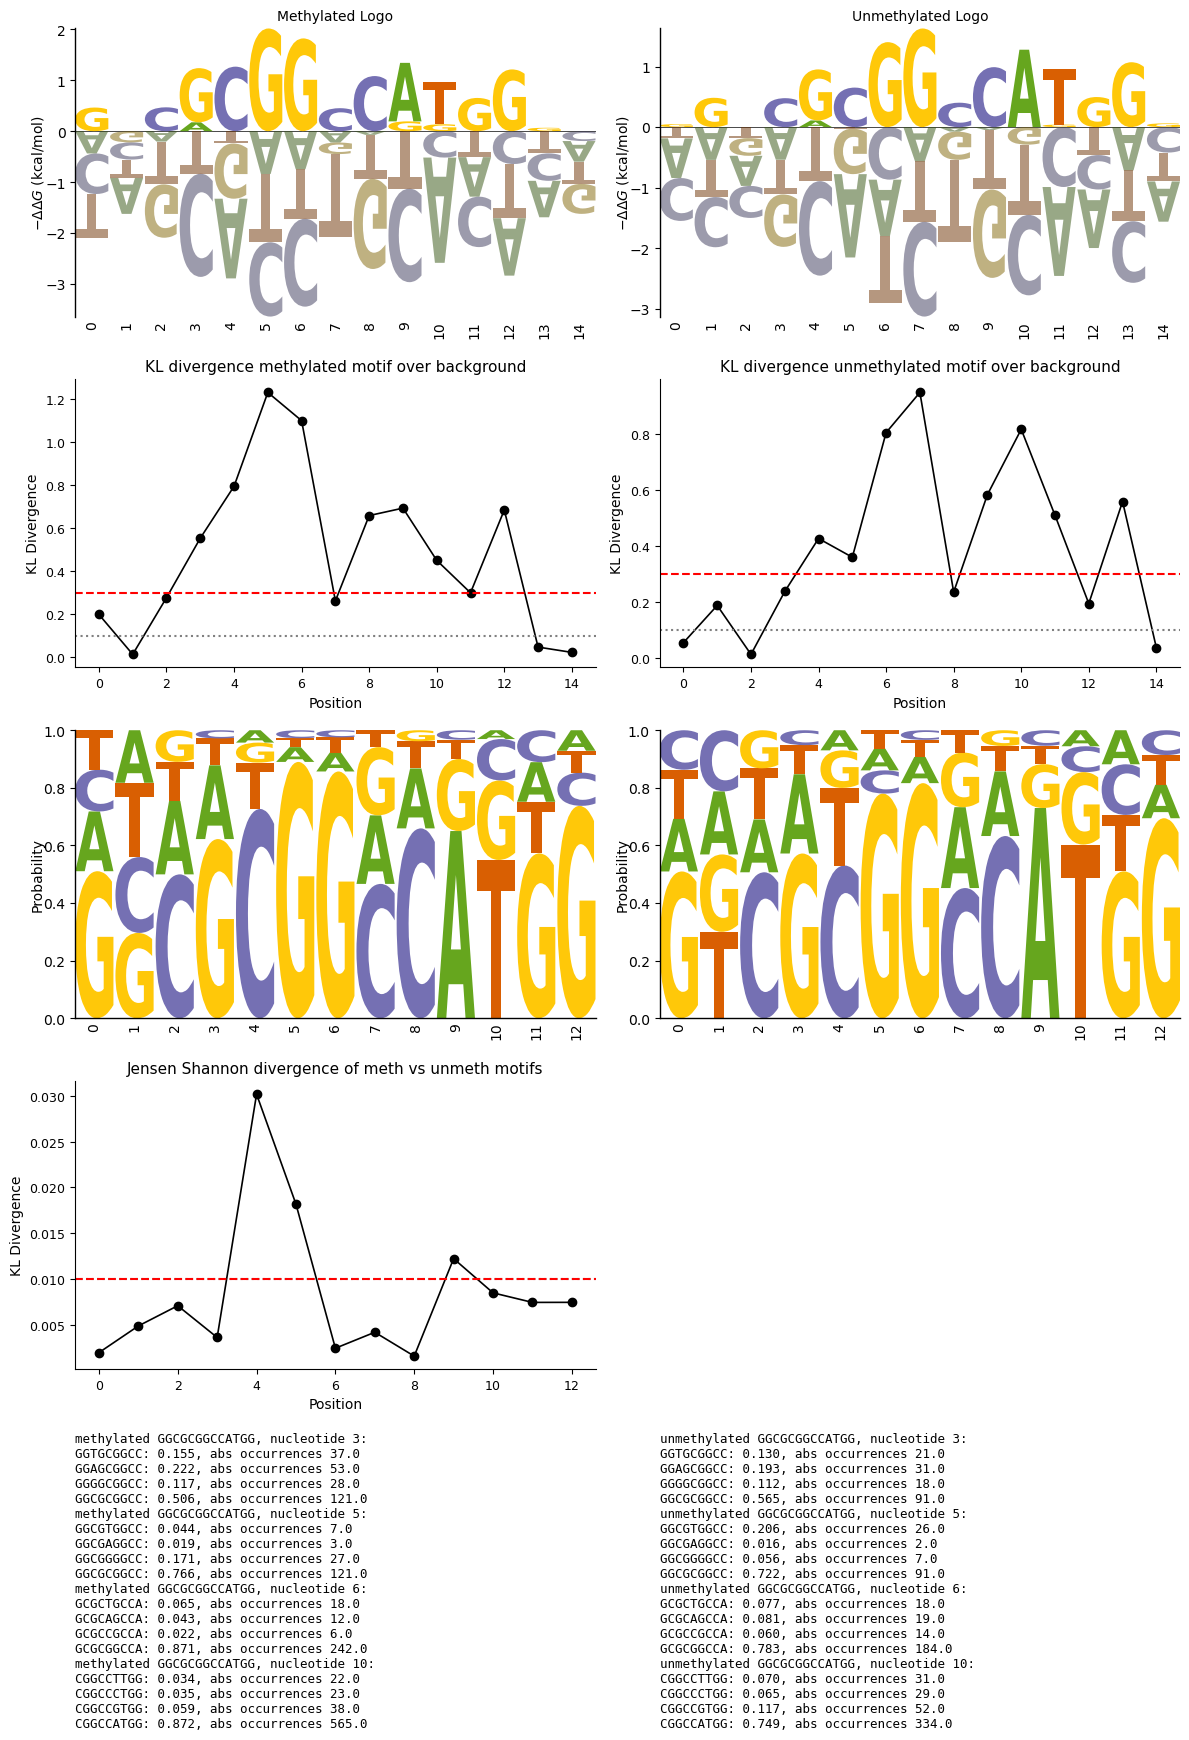

: 

In [ ]:
# PLOT THE EVERYTHING
fig = plt.figure(figsize=(12, 18))
gs = gridspec.GridSpec(5, 2, figure=fig)

# Define axes start with col 0
ax_dGGm = fig.add_subplot(gs[0, 0])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_m = fig.add_subplot(gs[1, 0])
ax_cons_ppm_m = fig.add_subplot(gs[2, 0])
ax_JS = fig.add_subplot(gs[3, 0])
ax_messages_m = fig.add_subplot(gs[4, 0])

# Top row joint logos and delta plots
ax_dGGum = fig.add_subplot(gs[0, 1])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_um = fig.add_subplot(gs[1, 1])
ax_cons_ppm_um = fig.add_subplot(gs[2, 1])
ax_messages_um = fig.add_subplot(gs[4, 1])


# Hide axes for messages (to be populated with text later)
ax_messages_m.axis('off')
ax_messages_um.axis('off')

# Plot
utils.make_logo(dGGm, ax=ax_dGGm, title='Methylated Logo')
utils.make_logo(dGGum, ax=ax_dGGum, title='Unmethylated Logo')
utils.plot_kl_divergence(c_kl_m, ax=ax_KL_m, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence methylated motif over background')
utils.plot_kl_divergence(c_kl_um, ax=ax_KL_um, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence unmethylated motif over background')
utils.ppm_logo(consensus_ppm_m, ax=ax_cons_ppm_m)
utils.ppm_logo(consensus_ppm_um, ax=ax_cons_ppm_um)

utils.plot_kl_divergence(c_js, ax=ax_JS, threshold_minor=js_threshold, threshold_major=js_threshold, title='Jensen Shannon divergence of meth vs unmeth motifs')
utils.plot_messages(printable_m, ax=ax_messages_m)
utils.plot_messages(printable_um, ax=ax_messages_um)

plt.tight_layout()
plt.savefig(os.path.join(data_path, f'{TF}_CG_statistic.pdf'), dpi=300)  


# Save the div series

s1 = c_kl_m
s1.name = 'KL_divergence_methylated'
s2 = c_kl_um
s2.name = 'KL_divergence_unmethylated'
s3 = c_js
s3.name = 'JensenShannon_divergence_mlib_ulib'

# Combine into a DataFrame
df = pd.concat([s1, s2, s3], axis=1)


# Save to CSV
df.to_csv(os.path.join(data_path, "divergence_series.csv"), index=False)


consensus_ppm_m.to_csv(os.path.join(data_path, "methylated_consensus_ppm_logo.csv"), index=False)
consensus_ppm_um.to_csv(os.path.join(data_path, "unmethylated_consensus_ppm_logo.csv"), index=False)

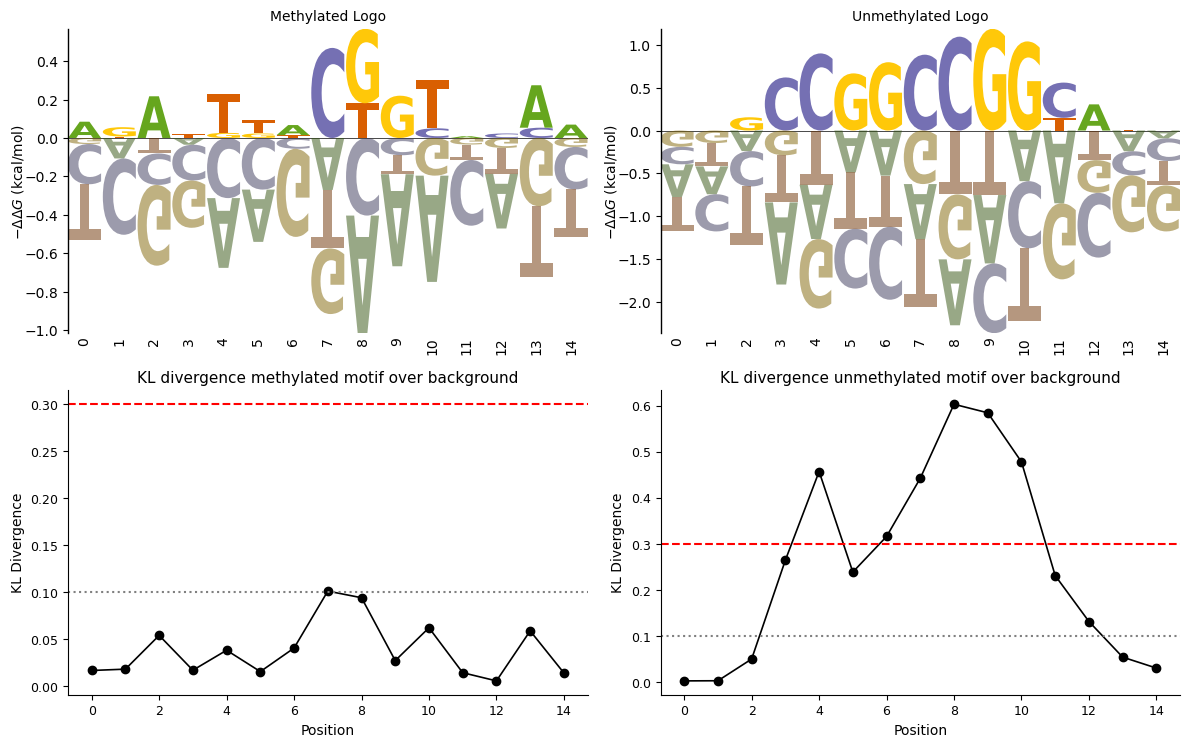

In [604]:
# In case mLib or uLib yields nothing, there is no point to make this analysis:
# PLOT THE EVERYTHING
fig = plt.figure(figsize=(12, 18))
gs = gridspec.GridSpec(5, 2, figure=fig)

# Define axes start with col 0
ax_dGGm = fig.add_subplot(gs[0, 0])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_m = fig.add_subplot(gs[1, 0])
#ax_cons_ppm_m = fig.add_subplot(gs[2, 0])
#ax_JS = fig.add_subplot(gs[3, 0])
#ax_messages_m = fig.add_subplot(gs[4, 0])

# Top row joint logos and delta plots
ax_dGGum = fig.add_subplot(gs[0, 1])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_um = fig.add_subplot(gs[1, 1])
#ax_cons_ppm_um = fig.add_subplot(gs[2, 1])
#ax_messages_um = fig.add_subplot(gs[4, 1])


# Hide axes for messages (to be populated with text later)
ax_messages_m.axis('off')
ax_messages_um.axis('off')

# Plot
utils.make_logo(dGGm, ax=ax_dGGm, title='Methylated Logo')
utils.make_logo(dGGum, ax=ax_dGGum, title='Unmethylated Logo')
utils.plot_kl_divergence(c_kl_m, ax=ax_KL_m, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence methylated motif over background')
utils.plot_kl_divergence(c_kl_um, ax=ax_KL_um, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence unmethylated motif over background')
#utils.ppm_logo(consensus_ppm_m, ax=ax_cons_ppm_m)
#utils.ppm_logo(consensus_ppm_um, ax=ax_cons_ppm_um)

#utils.plot_kl_divergence(c_js, ax=ax_JS, threshold_minor=js_threshold, threshold_major=js_threshold, title='Jensen Shannon divergence of meth vs unmeth motifs')
#utils.plot_messages(printable_m, ax=ax_messages_m)
#utils.plot_messages(printable_um, ax=ax_messages_um)

plt.tight_layout()
plt.savefig(os.path.join(data_path, f'{TF}_CG_statistics.pdf'), dpi=300)  

s1 = c_kl_m
s1.name = 'KL_divergence_methylated'
s2 = c_kl_um
s2.name = 'KL_divergence_unmethylated'

# Combine into a DataFrame
df = pd.concat([s1, s2], axis=1)


# Save to CSV
df.to_csv(os.path.join(data_path, "divergence_series.csv"), index=False)

consensus_ppm_m.to_csv(os.path.join(data_path, "methylated_consensus_ppm_logo.csv"), index=False)
consensus_ppm_um.to_csv(os.path.join(data_path, "unmethylated_consensus_ppm_logo.csv"), index=False)

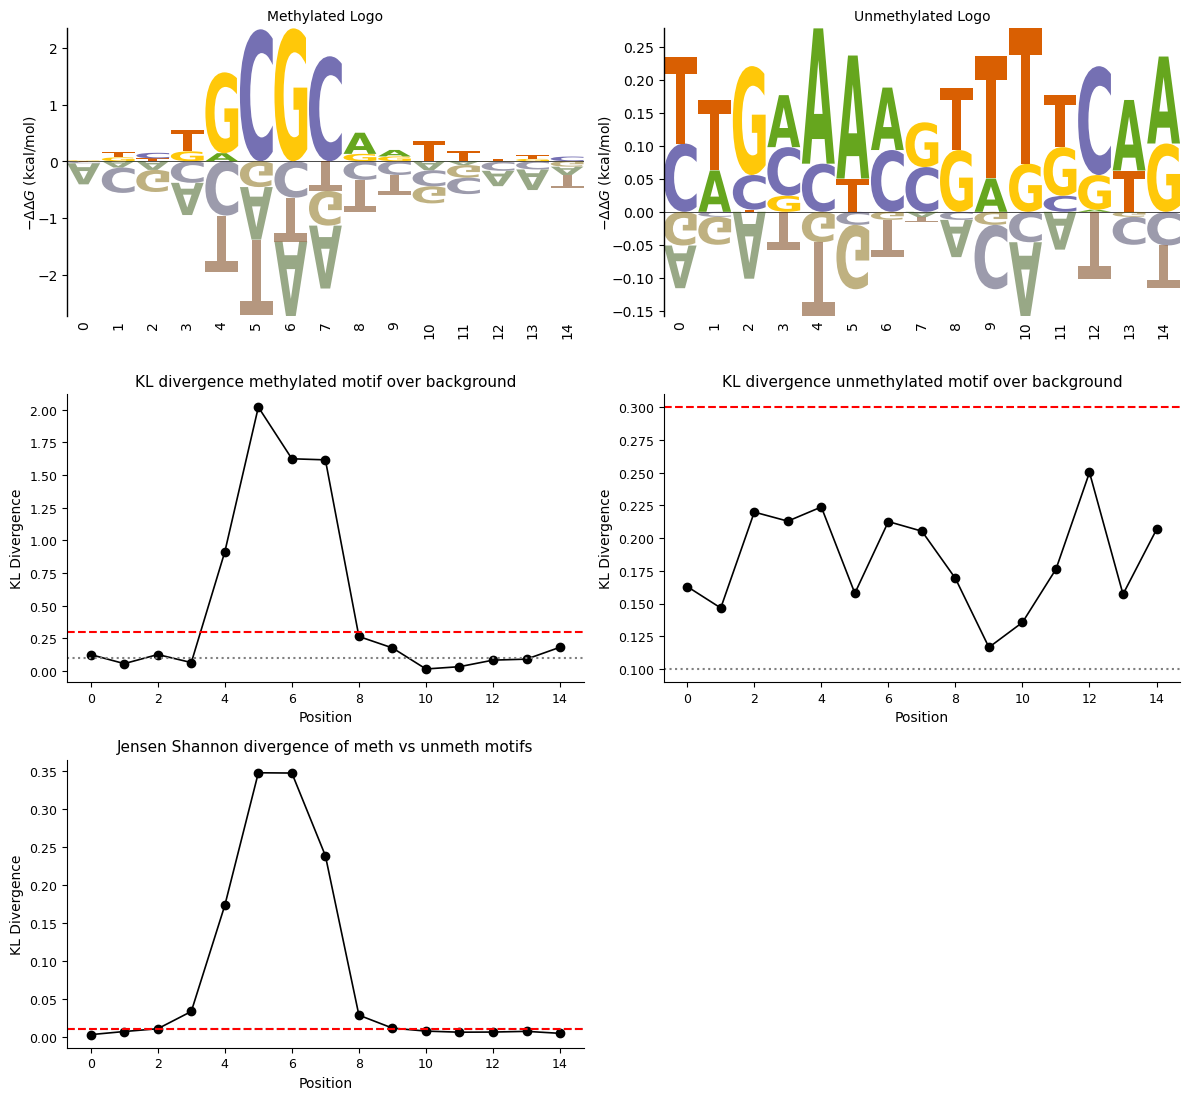

In [121]:
# In case there is no difference between motifs:
# PLOT THE EVERYTHING
fig = plt.figure(figsize=(12, 18))
gs = gridspec.GridSpec(5, 2, figure=fig)

# Define axes start with col 0
ax_dGGm = fig.add_subplot(gs[0, 0])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_m = fig.add_subplot(gs[1, 0])
#ax_cons_ppm_m = fig.add_subplot(gs[2, 0])
ax_JS = fig.add_subplot(gs[2, 0])
#ax_messages_m = fig.add_subplot(gs[4, 0])

# Top row joint logos and delta plots
ax_dGGum = fig.add_subplot(gs[0, 1])  # Rows 0-1, Col 0 (scatterplot)
ax_KL_um = fig.add_subplot(gs[1, 1])
#ax_cons_ppm_um = fig.add_subplot(gs[2, 1])
#ax_messages_um = fig.add_subplot(gs[4, 1])


# Hide axes for messages (to be populated with text later)
ax_messages_m.axis('off')
ax_messages_um.axis('off')

# Plot
utils.make_logo(dGGm, ax=ax_dGGm, title='Methylated Logo')
utils.make_logo(dGGum, ax=ax_dGGum, title='Unmethylated Logo')
utils.plot_kl_divergence(c_kl_m, ax=ax_KL_m, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence methylated motif over background')
utils.plot_kl_divergence(c_kl_um, ax=ax_KL_um, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence unmethylated motif over background')
#utils.ppm_logo(consensus_ppm_m, ax=ax_cons_ppm_m)
#utils.ppm_logo(consensus_ppm_um, ax=ax_cons_ppm_um)

utils.plot_kl_divergence(c_js, ax=ax_JS, threshold_minor=js_threshold, threshold_major=js_threshold, title='Jensen Shannon divergence of meth vs unmeth motifs')
#utils.plot_messages(printable_m, ax=ax_messages_m)
#utils.plot_messages(printable_um, ax=ax_messages_um)

plt.tight_layout()
plt.savefig(os.path.join(data_path, f'{TF}_CG_statistics.pdf'), dpi=300)  

# Save the div series

s1 = c_kl_m
s1.name = 'KL_divergence_methylated'
s2 = c_kl_um
s2.name = 'KL_divergence_unmethylated'
s3 = c_js
s3.name = 'JensenShannon_divergence_mlib_ulib'

# Combine into a DataFrame
df = pd.concat([s1, s2, s3], axis=1)


# Save to CSV
df.to_csv(os.path.join(data_path, "divergence_series.csv"), index=False)

consensus_ppm_m.to_csv(os.path.join(data_path, "methylated_consensus_ppm_logo.csv"), index=False)
consensus_ppm_um.to_csv(os.path.join(data_path, "unmethylated_consensus_ppm_logo.csv"), index=False)

None of the values surpass the threshold, returning original series.


/tmp/ipykernel_3808010/129656276.py:265: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_3808010/129656276.py:265: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_3808010/129656276.py:265: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


None of the values surpass the threshold, returning original series.
None of the values surpass the threshold, returning original series.


IndexError: string index out of range

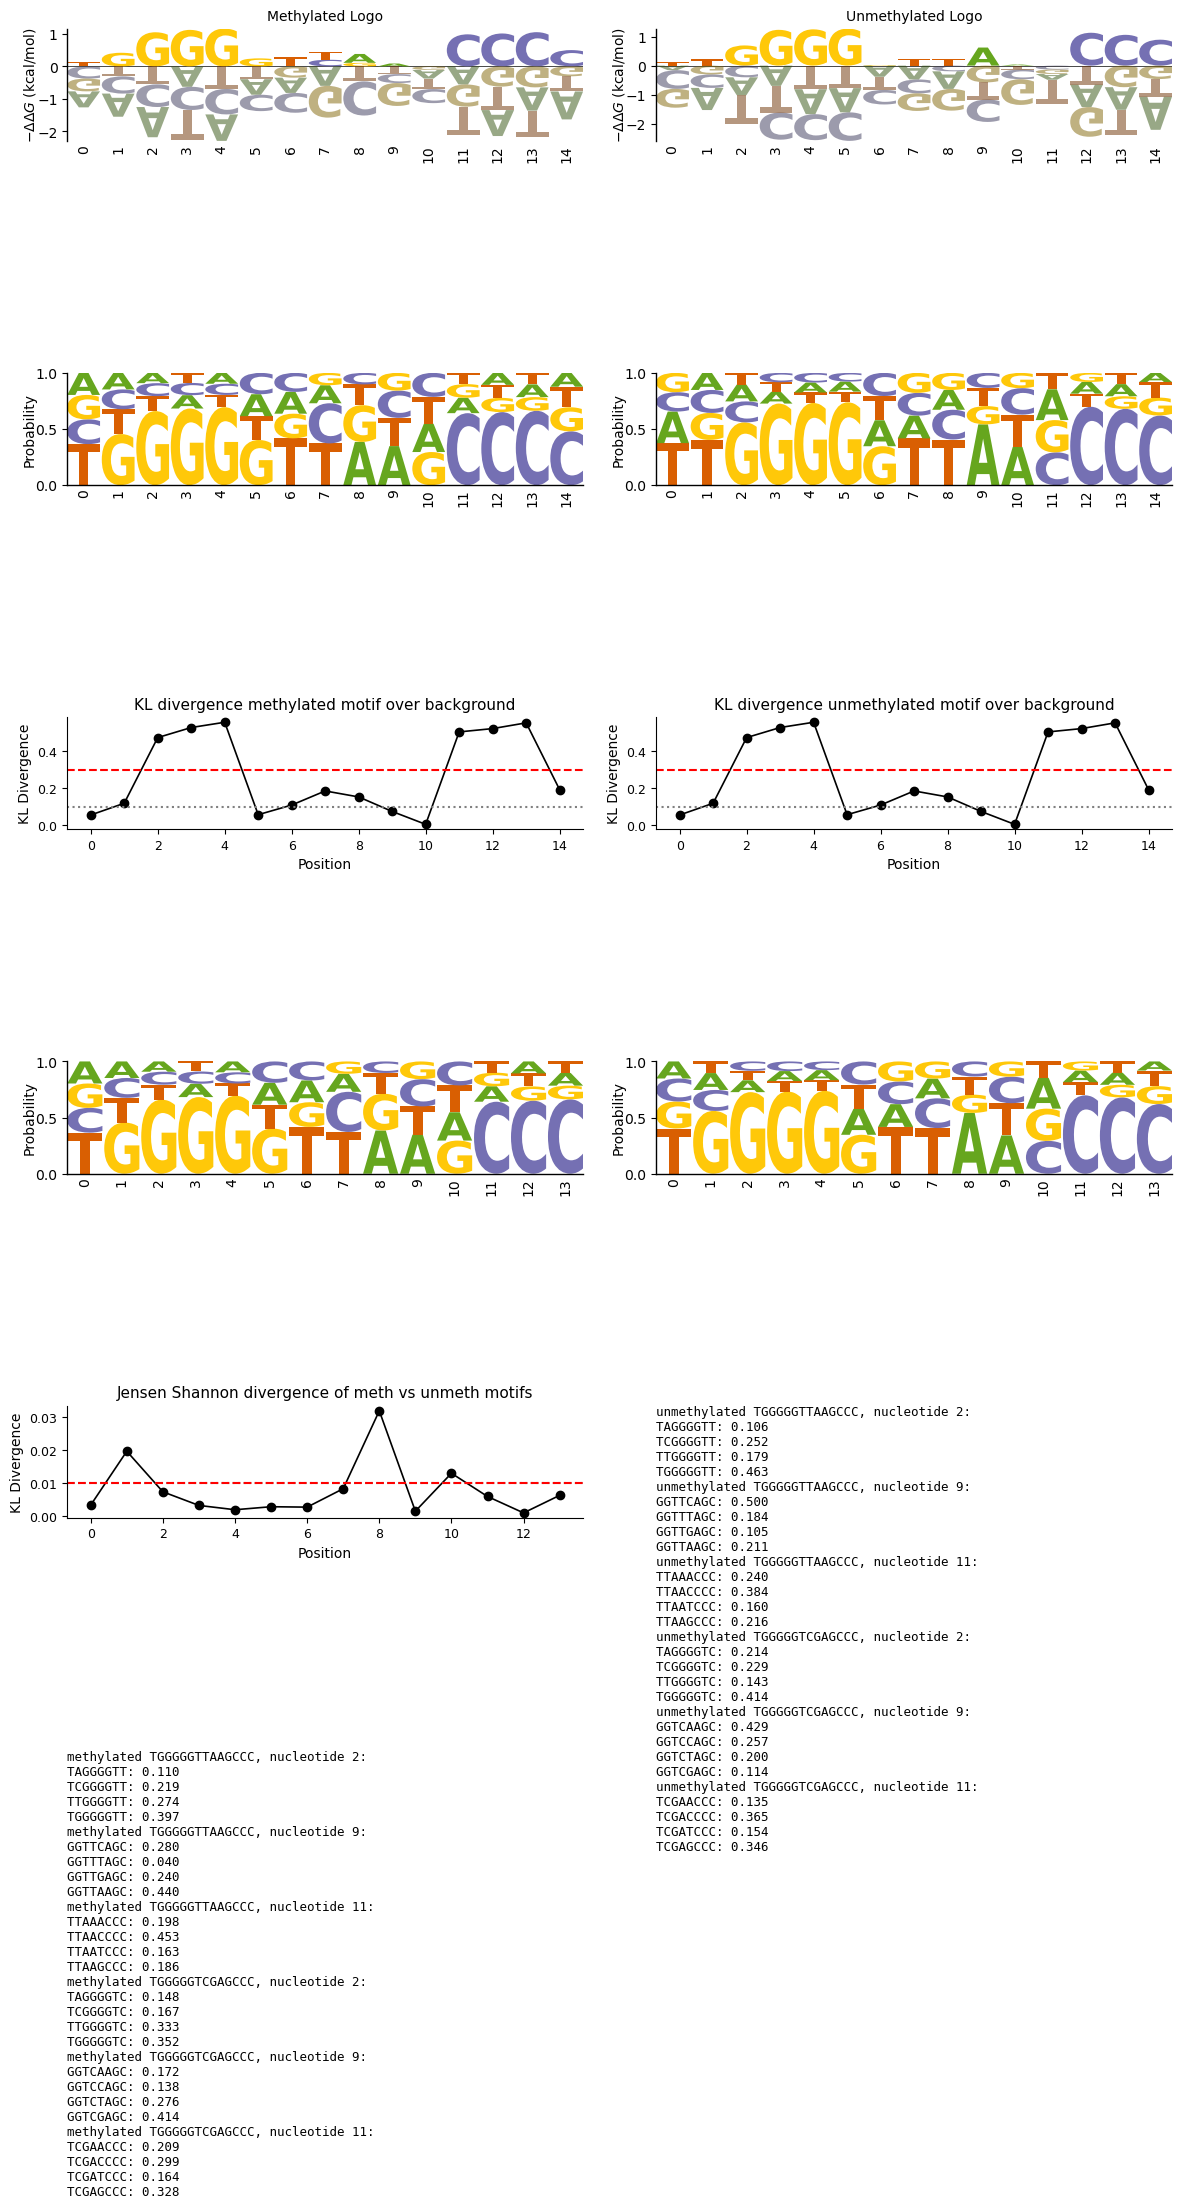

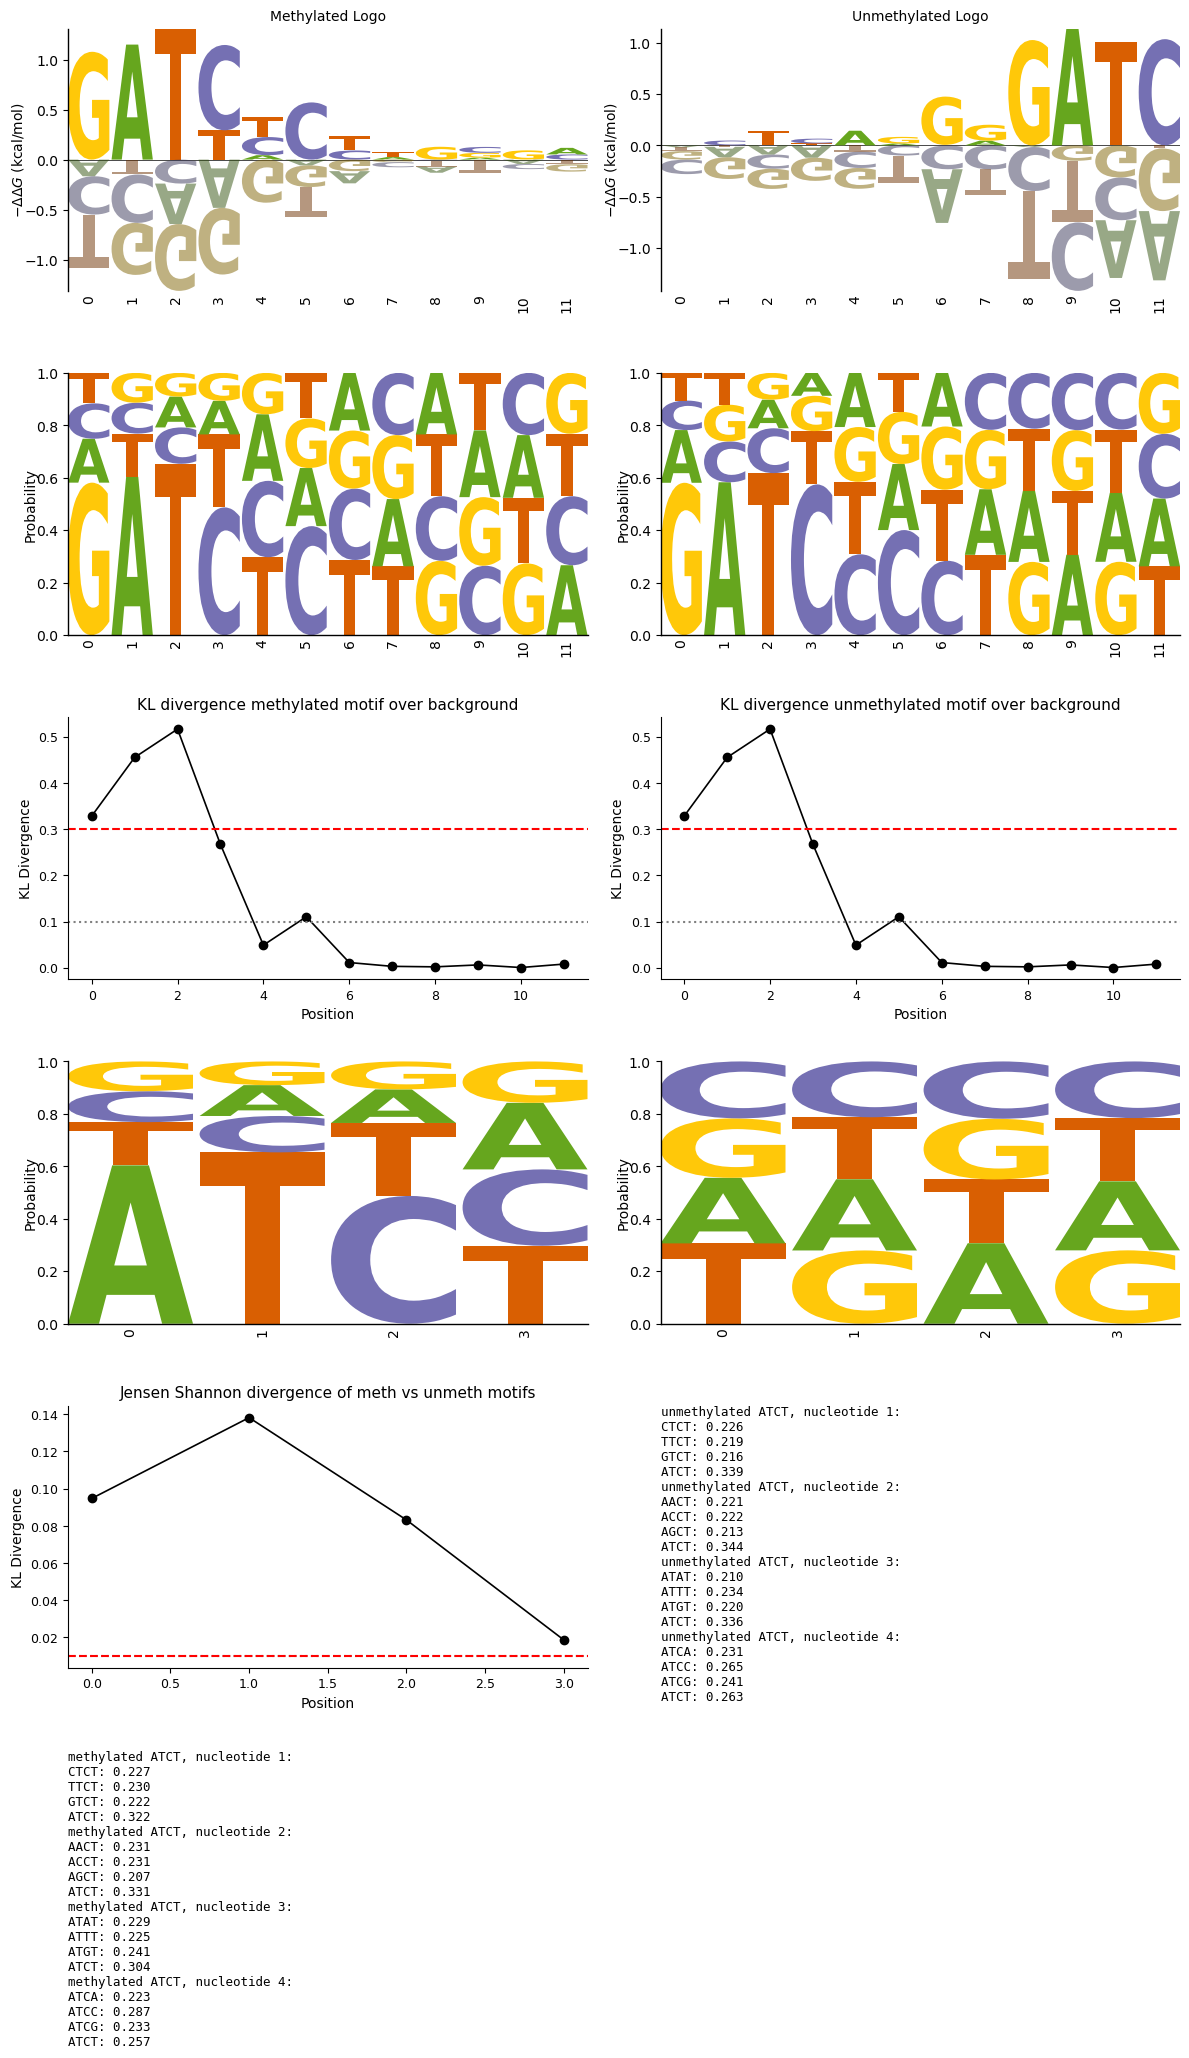

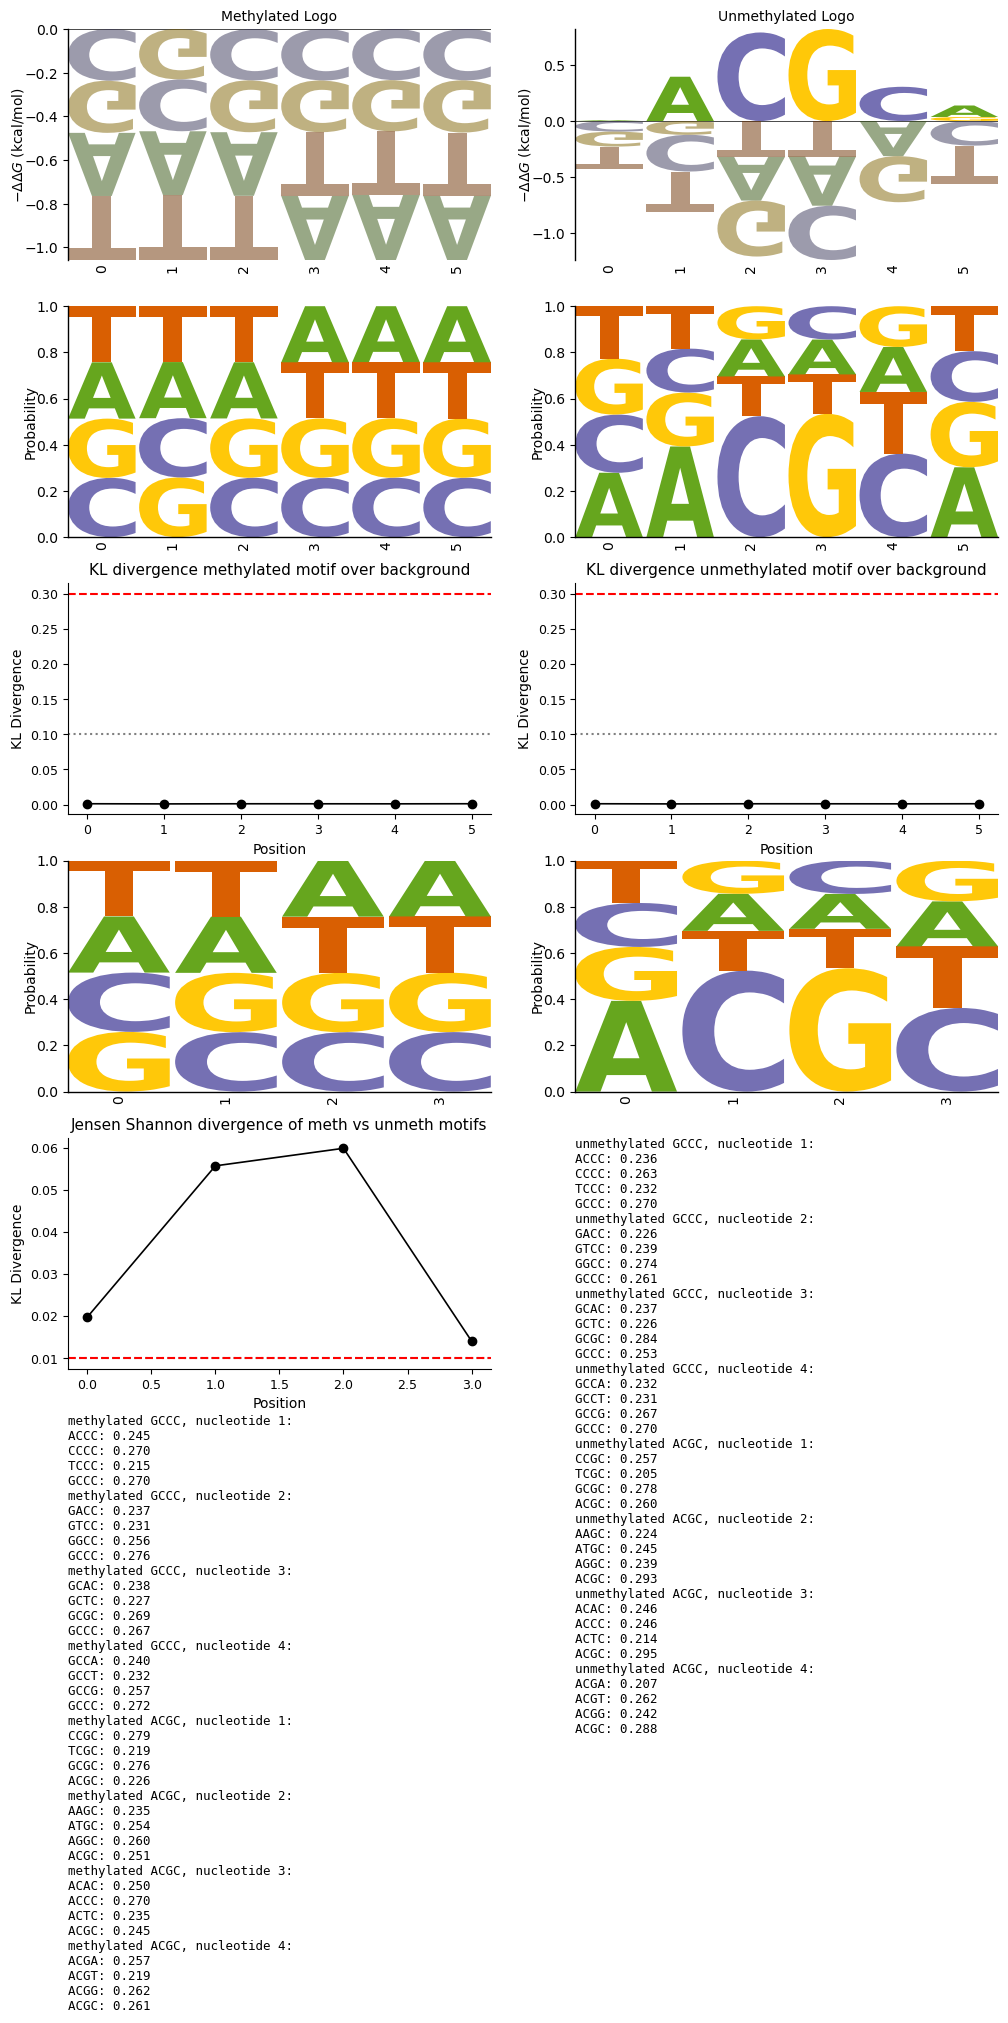

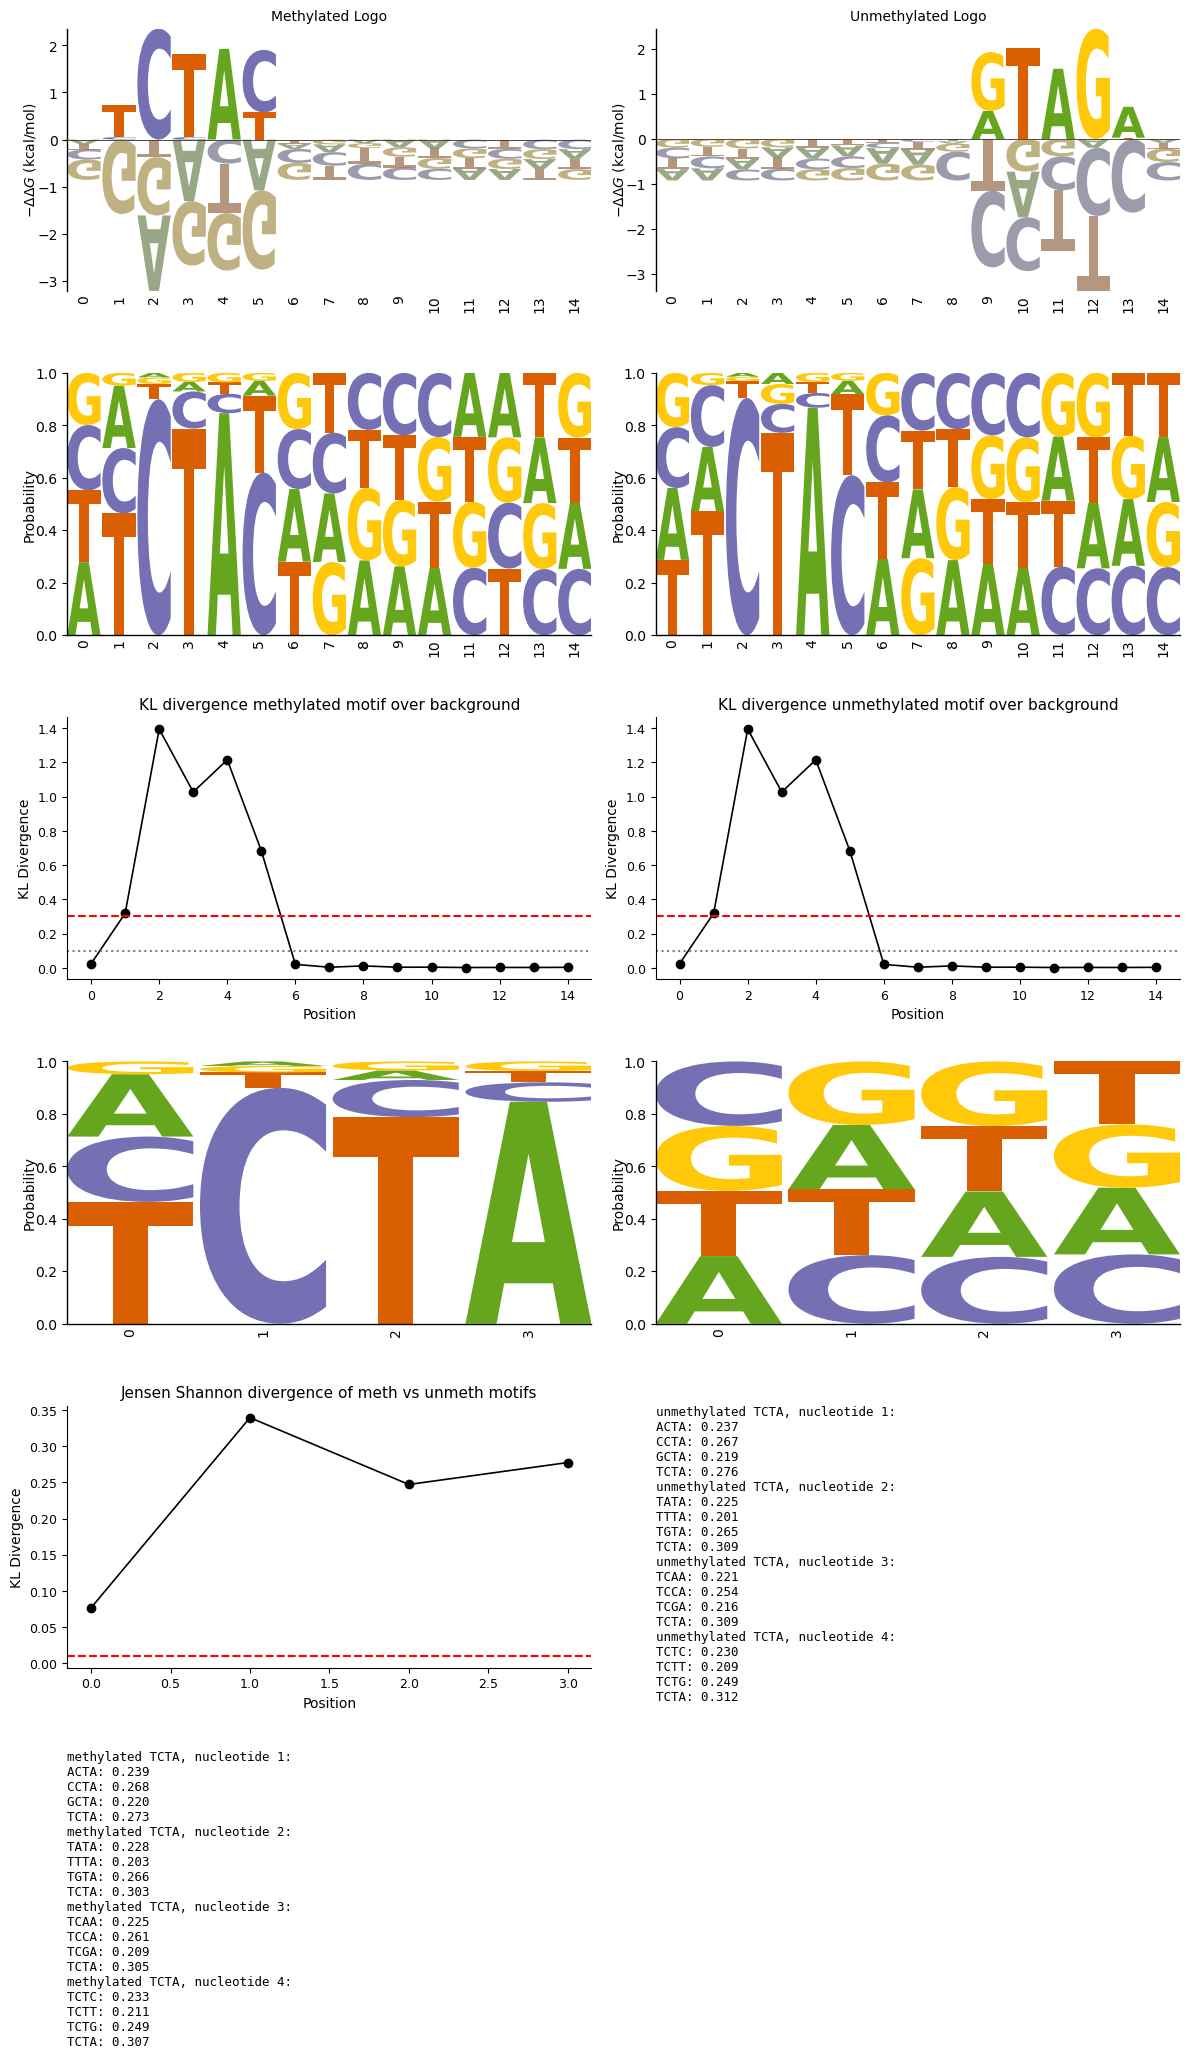

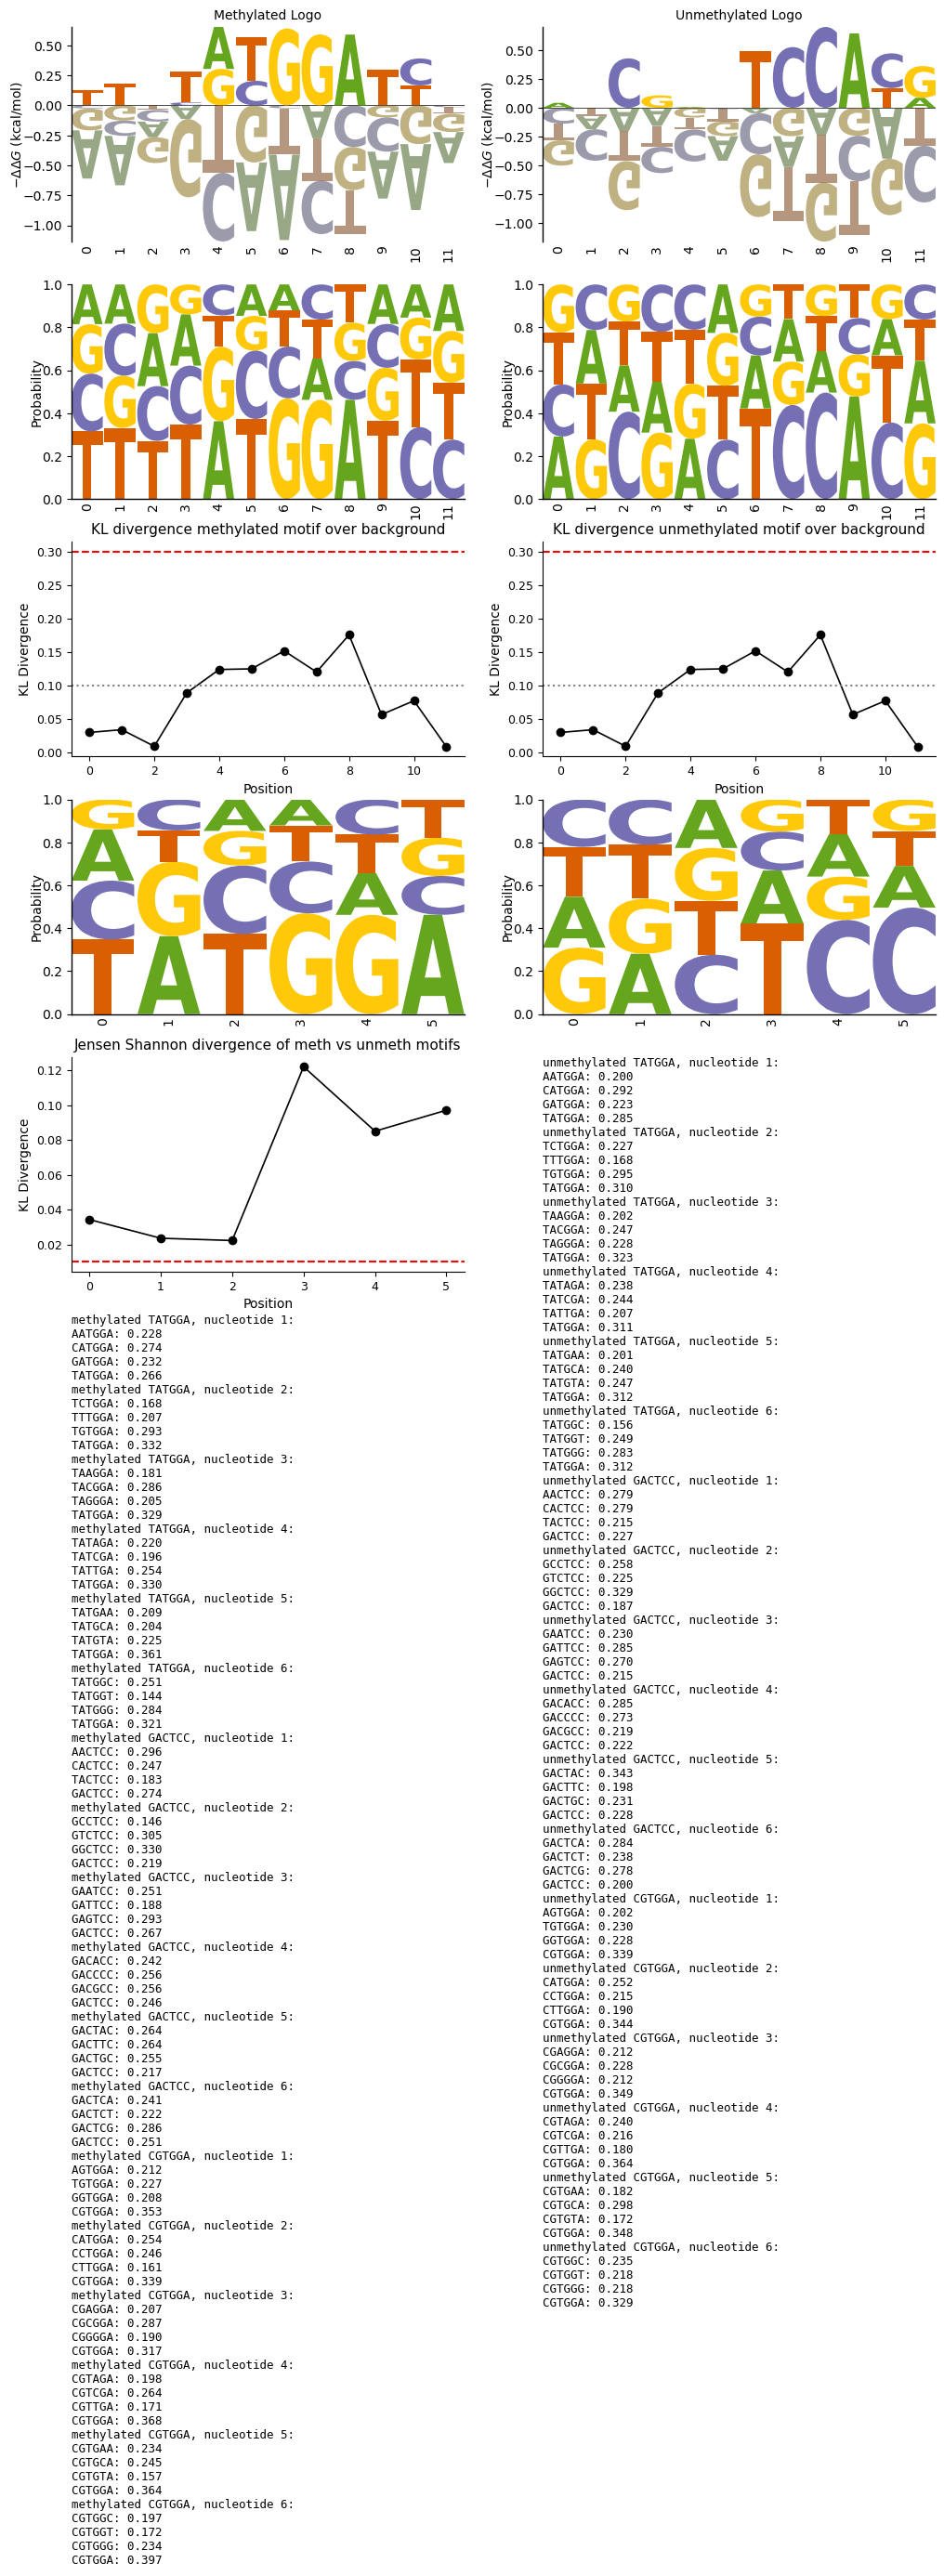

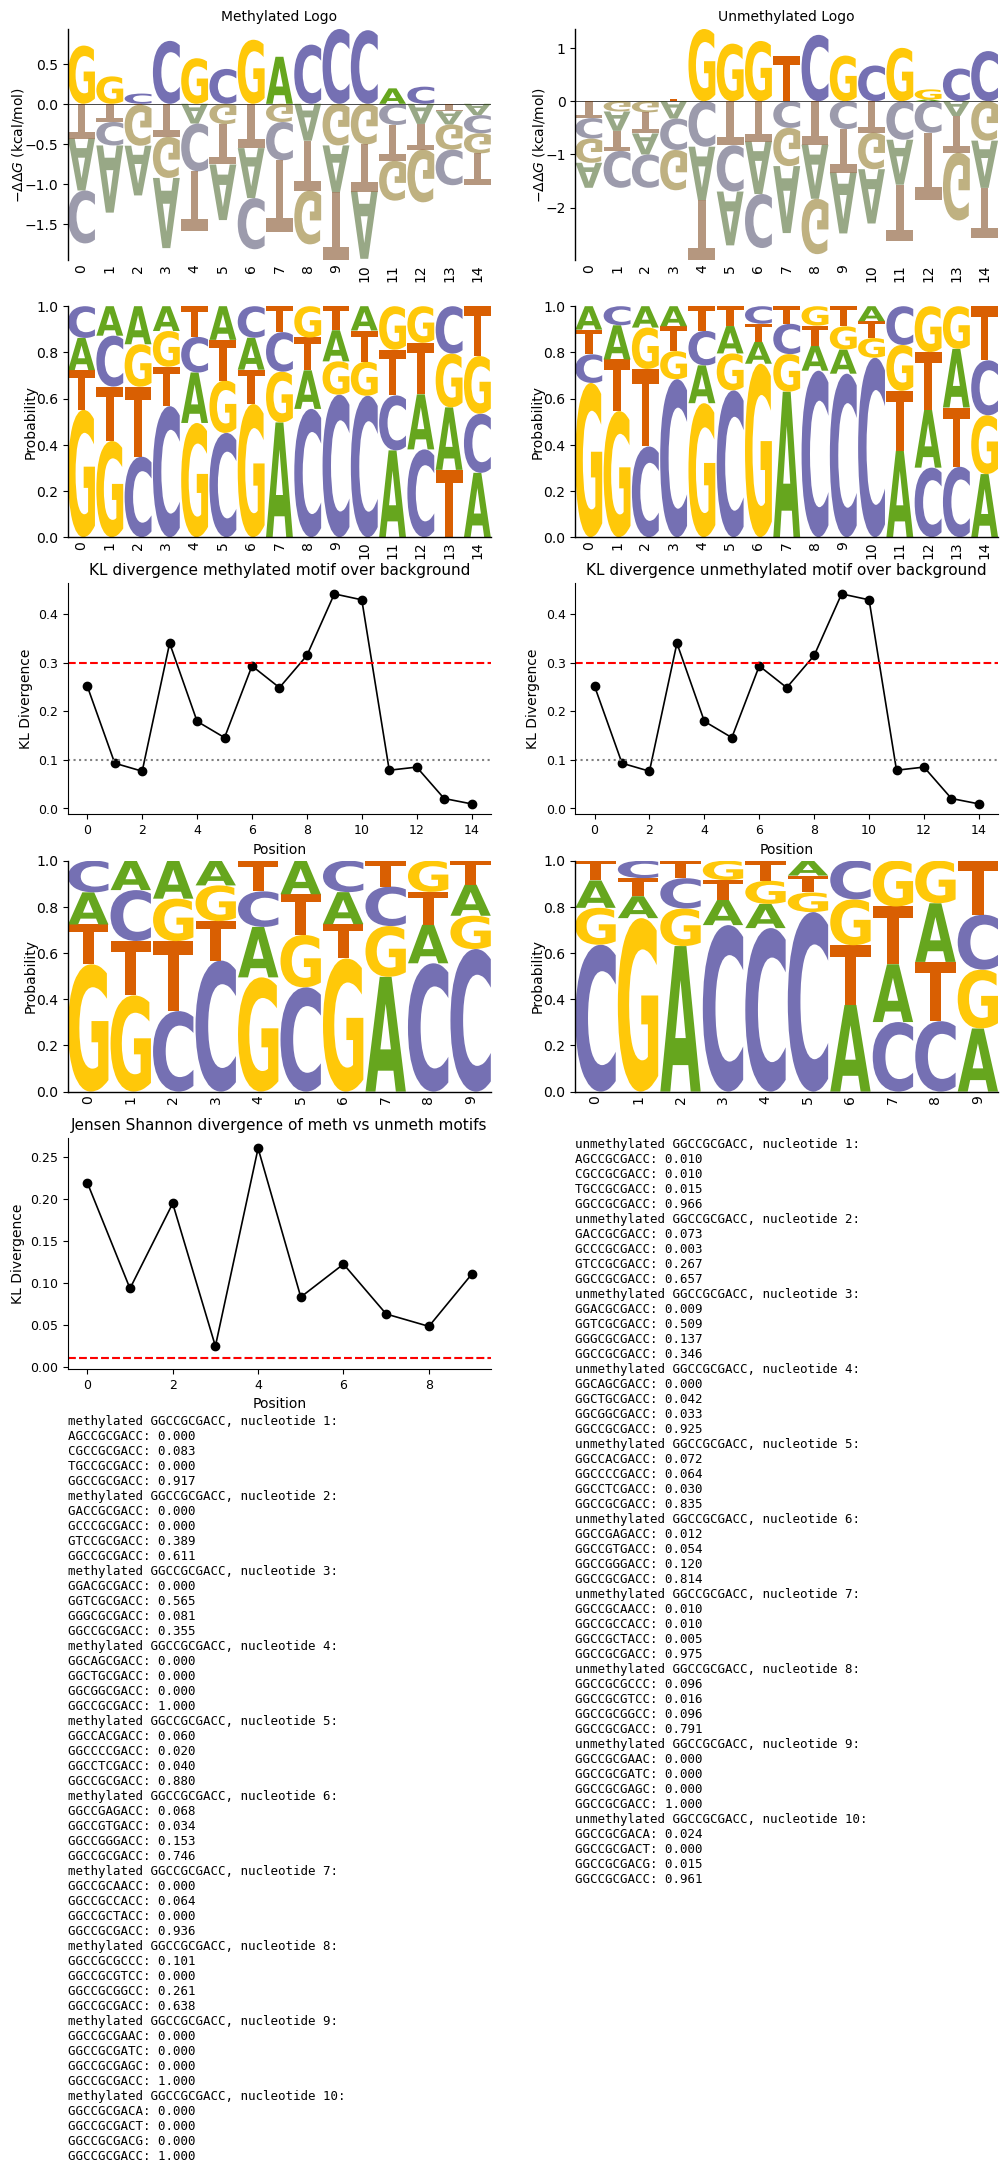

In [25]:
for TF in filtered_TFs:
    data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
    
        
    sep_matrices_path = os.path.join(data_path, 'separated/matrices/')


    files_sep = os.listdir(sep_matrices_path)
    meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
    unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]


    dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
    dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)


    ##############
    #Getting all the paths for the raw data, looks ugly and it is
    SMSAGxx = latest_curation[latest_curation.TF == TF].exp.values[0]
    BC = metadata[(metadata['TF'] == TF) & (metadata['experiment'] == SMSAGxx)].Chip_pos.values[0]
    put_in = metadata[(metadata['TF'] == TF) & (metadata['experiment'] == SMSAGxx)].input_library.values[0]

    SMSAGxx = metadata_dict[SMSAGxx]
    

    mBC, umBC, input_path = assign_mBC(put_in)
    
    input_path = os.path.join(input_path, f'BC{BC}_contamination_filtered.csv')
    ########
    #load the stuff
    BC_in = pd.read_csv(input_path)
    
    df_in = pd.read_csv(
        f'~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/{SMSAGxx}/00_read_in_data/output/BC{BC}_contamination_filtered.csv'
    )

    in_m = BC_in[BC_in['methl'] == mBC].reset_index(drop=True)
    in_nm = BC_in[BC_in['methl'] == umBC].reset_index(drop=True)

    df_m = df_in[df_in['methl'] == mBC].reset_index(drop=True)
    df_nm = df_in[df_in['methl'] == umBC].reset_index(drop=True)

    #############################
    # Now let the fun begin
    # Strategy: take ddG, make probability matrix. Take background probability, calculate per position KL divergence
    # (how much the logo diverges from the background). Take first and last position of logo and crop for consensus.
    # Then, identify CG positions in both consensus sequences, also calculate the Jensen Shannon divergence between them
    # to identify positions in which the sequences diverge from each other (threshold 0.01). To circumvent problem with
    # too sparse data/too long consensus sequences: If consensus is longer than 11, split it into two words with 8 nt.
    # Mutate each identified position and calculate the probability of the word in the raw data. Print the words and 
    # occurrencies in a human readable form.

    #Convert ProBOund logos into probabilites
    psam_m = utils.ddG_to_psam(dGGm)
    psam_um = utils.ddG_to_psam(dGGum)

    ppm_m = utils.pfm_to_ppm(psam_m)
    ppm_um = utils.pfm_to_ppm(psam_um)

    #Estimate nucleotide distribution in background
    nuc_m = utils.estimate_nucleotide_distribution(in_m, seq_col='random24')
    nuc_um = utils.estimate_nucleotide_distribution(in_nm, seq_col='random24')

    #Calculate KL diveregences between ppm and background and crop consensus
    c_kl_m = utils.compute_kl_divergence(ppm_m, nuc_m)
    c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um)  

    cropped_m = utils.crop_consensus(c_kl_m, threshold=kl_threshold)
    cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)# here is a possibility to plot KL_divergence

    # In case the consensus sequences are not the same lenght, align the consensus based on hamming distance

    adj_idx_m, adj_idx_um = utils.optimal_consensus_alignment(
                            cropped_m, cropped_um,
                            dGGm, dGGum,
                            max_shift=1
                        )

    # Create a character string comprising the consensus sequence of the methylated and unmethylated library
    cons_m = utils.ddg_to_consensus(dGGm.loc[adj_idx_m,:])
    cons_um = utils.ddg_to_consensus(dGGum.loc[adj_idx_um,:])

   
    # compare and align if needed, take rev complement
    min_val = len(utils.where_difference(cons_m, cons_um))
    result = len(utils.where_difference(cons_m, utils.rev_complement_seq(cons_um)))
    if result < min_val:
        ppm_um = utils.rev_complement(ppm_um, extended_alphabet=False)
        c_kl_um = utils.compute_kl_divergence(ppm_um, nuc_um) 
        cropped_um = utils.crop_consensus(c_kl_um, threshold=kl_threshold)
        cons_um = utils.rev_complement_seq(cons_um)



    # Identify where CGs are in both consensus sequences, then calculate jenson shannon div
    CGm = utils.where_CG(cons_m)
    CGum = utils.where_CG(cons_um)

    CG = set(CGm + CGum)



    # Identify differences in KL filtered consensus based on jensen shannon divergence (threshold 0.01)
    consensus_ppm_m = ppm_m.loc[adj_idx_m,:].reset_index(drop=True)
    consensus_ppm_um = ppm_um.loc[adj_idx_um,:].reset_index(drop=True)
    c_js = utils.jensen_shannon_divergence(consensus_ppm_m, consensus_ppm_um)

    js_div = list(c_js[c_js >= js_threshold].index) # Here is another possibility to plot the difference between the plots.


    differences = utils.resolve_cg_js_div(CG=CG, js_div=js_div)



    # look for the two consensus sequences, if their hamming distance is greater than 1, append both consensus sequences to list
    diff = utils.hamming_distance(cons_m, cons_um)
    if diff > 1:
        consensus_seqs = [cons_m, cons_um]
    else:
        consensus_seqs = [cons_m]



    # What if there are secondary CGs that aer not picked up by consensus?
    check_secondary_CG_sequences_m = utils.find_stabilizing_CG(dGGm.loc[adj_idx_m,:].reset_index(drop=True))
    check_secondary_CG_sequences_um = utils.find_stabilizing_CG(dGGum.loc[adj_idx_um,:].reset_index(drop=True))

    for id in check_secondary_CG_sequences_m:
        if not cons_m[id] == 'C' and not cons_m[id+1] == 'G':
            sec_cons_m = list(cons_m)
            sec_cons_m[id] = 'C'
            sec_cons_m[id+1] = 'G'
            sec_cons_m = ''.join(sec_cons_m)
            consensus_seqs.append(sec_cons_m)
    
    for id in check_secondary_CG_sequences_um:
        if not cons_um[id] == 'C' and not cons_um[id+1] == 'G':
            sec_cons_um = list(cons_um)
            sec_cons_um[id] = 'C'
            sec_cons_um[id+1] = 'G'
            sec_cons_um = ''.join(sec_cons_um)
            consensus_seqs.append(sec_cons_um)



    # And now search for the words in the raw data
    printable_m = []
    printable_um = []
    for sequence in consensus_seqs:
        for posi in differences:
            if len(sequence) > 10:
                k = 8
                _k = k//2
                k_ = k - _k
                if posi - _k < 0:
                    frag = sequence[0:k]
                    p = posi
                elif posi + k_ > len(sequence):
                    frag = sequence[-k:]
                    last_index = len(sequence) - 1
                    p = last_index - k
                else:
                    frag = sequence[posi-_k:posi+k_]
                    p = _k
            else:
                k = len(sequence)
                frag = sequence
                p = posi

            search_for = []
            search_for.extend(utils.single_point_mut_seq(frag, p))
            search_for.append(frag)

            search_for_rev = [utils.rev_complement_seq(i) for i in search_for]
            
            search_for_rev.extend(search_for)

            pattern = '|'.join(search_for_rev)
            consens_m = df_m[df_m['random24'].str.contains(pattern, regex=True)]
            consens_um = df_nm[df_nm['random24'].str.contains(pattern, regex=True)]

            consens_kmer_m = utils.kmer_counting(consens_m, kmer=k,one_df=True)
            consens_kmer_um = utils.kmer_counting(consens_um, kmer=k,one_df=True)

        ##################
            distrib_m = {}
            wrd_n = 0
            for word in search_for:
                freq = consens_kmer_m[consens_kmer_m['kmer'].str.contains(word, regex=True)]['count'].sum()
                freq += consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
                wrd_n += freq

                distrib_m[word] = freq

            distrib_m['sum'] = wrd_n

            printable_m.append(f'methylated {sequence}, nucleotide {posi+1}:')
            for word in search_for:
                fraction = distrib_m[word] / distrib_m['sum']
                printable_m.append(f"{word}: {fraction:.3f}")

            

        ###################
            distrib_um = {}
            wrd_n = 0
            for word in search_for:
                freq = consens_kmer_um[consens_kmer_um['kmer'].str.contains(word, regex=True)]['count'].sum()
                freq += consens_kmer_um[consens_kmer_um['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
                wrd_n += freq
                distrib_um[word] = freq

            distrib_um['sum'] = wrd_n

            printable_um.append(f'unmethylated {sequence}, nucleotide {posi+1}:')
            for word in search_for:
                fraction = distrib_um[word] / distrib_um['sum']
                printable_um.append(f"{word}: {fraction:.3f}")
            

    #message_text_m = "\n".join(printable_m)
    #print(message_text_m)
    #message_text_um = "\n".join(printable_um)
    #print(message_text_um)


    # PLOT THE EVERYTHING
    fig = plt.figure(figsize=(12, 21))
    gs = gridspec.GridSpec(6, 2, figure=fig)

    # Define axes start with col 0
    ax_dGGm = fig.add_subplot(gs[0, 0])  # Rows 0-1, Col 0 (scatterplot)
    ax_ppm_m = fig.add_subplot(gs[1, 0])
    ax_KL_m = fig.add_subplot(gs[2, 0])
    ax_cons_ppm_m = fig.add_subplot(gs[3, 0])
    ax_JS = fig.add_subplot(gs[4, 0])
    ax_messages_m = fig.add_subplot(gs[5, 0])

    # Top row joint logos and delta plots
    ax_dGGum = fig.add_subplot(gs[0, 1])  # Rows 0-1, Col 0 (scatterplot)
    ax_ppm_um = fig.add_subplot(gs[1, 1])
    ax_KL_um = fig.add_subplot(gs[2, 1])
    ax_cons_ppm_um = fig.add_subplot(gs[3, 1])
    ax_messages_um = fig.add_subplot(gs[4, 1])
    

    # Hide axes for messages (to be populated with text later)
    ax_messages_m.axis('off')
    ax_messages_um.axis('off')

    # Plot
    utils.make_logo(dGGm, ax=ax_dGGm, title='Methylated Logo')
    utils.make_logo(dGGum, ax=ax_dGGum, title='Unmethylated Logo')
    utils.ppm_logo(ppm_m, ax=ax_ppm_m)
    utils.ppm_logo(ppm_um, ax=ax_ppm_um)
    utils.plot_kl_divergence(c_kl_m, ax=ax_KL_m, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence methylated motif over background')
    utils.plot_kl_divergence(c_kl_m, ax=ax_KL_um, threshold_major=0.3, threshold_minor=kl_threshold, title='KL divergence unmethylated motif over background')
    utils.ppm_logo(consensus_ppm_m, ax=ax_cons_ppm_m)
    utils.ppm_logo(consensus_ppm_um, ax=ax_cons_ppm_um)

    utils.plot_kl_divergence(c_js, ax=ax_JS, threshold_minor=js_threshold, threshold_major=js_threshold, title='Jensen Shannon divergence of meth vs unmeth motifs')
    utils.plot_messages(printable_m, ax=ax_messages_m)
    utils.plot_messages(printable_um, ax=ax_messages_um)

    plt.tight_layout()

    plt.savefig(os.path.join(data_path, f'{TF}_CG_statistics.pdf'), dpi=300)    
    
    



In [30]:
c_js

0     0.003342
1     0.019622
2     0.007357
3     0.003233
4     0.001931
5     0.002841
6     0.002717
7     0.008291
8     0.031851
9     0.001493
10    0.012963
11    0.005940
12    0.000974
13    0.006278
dtype: float64

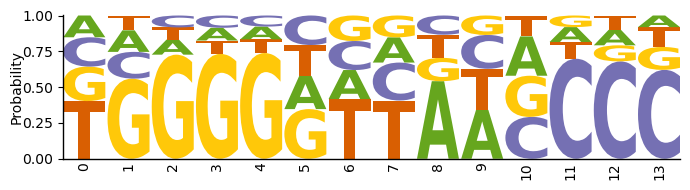

In [29]:
utils.ppm_logo(consensus_ppm_um)

In [30]:
utils.jensen_shannon_divergence(consensus_ppm_m, consensus_ppm_um)

0     0.003342
1     0.019622
2     0.007357
3     0.003233
4     0.001931
5     0.002841
6     0.002717
7     0.008291
8     0.031851
9     0.001493
10    0.012963
11    0.005940
12    0.000974
13    0.006278
dtype: float64

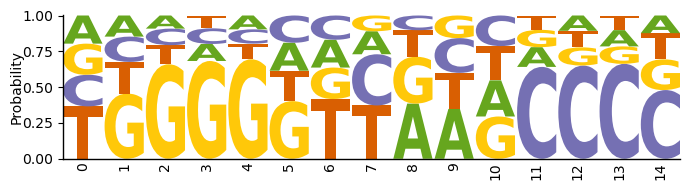

In [16]:
utils.ppm_logo(ppm_m)

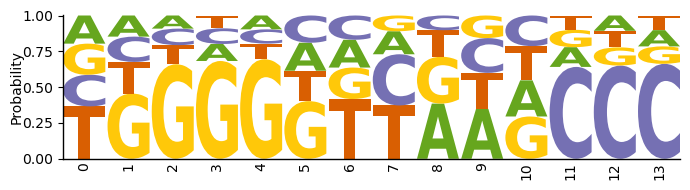

In [15]:
utils.ppm_logo(ppm_m.loc[adj_idx_m,:])

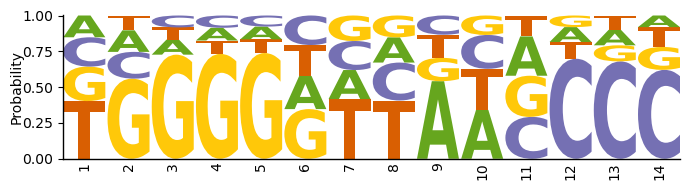

In [17]:
utils.ppm_logo(ppm_um.loc[adj_idx_um,:])

In [19]:
utils.jensen_shannon_divergence(ppm_m.loc[adj_idx_m,:].reset_index(drop=True), ppm_um.loc[adj_idx_um,:].reset_index(drop=True))

0     0.003342
1     0.019622
2     0.007357
3     0.003233
4     0.001931
5     0.002841
6     0.002717
7     0.008291
8     0.031851
9     0.001493
10    0.012963
11    0.005940
12    0.000974
13    0.006278
dtype: float64

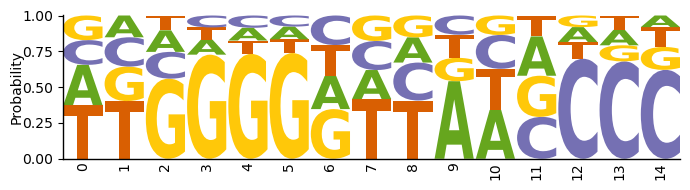

In [14]:
utils.ppm_logo(ppm_um)

In [11]:
c_js

0     0.019622
1     0.007357
2     0.003233
3     0.001931
4     0.002841
5     0.002717
6     0.008291
7     0.031851
8     0.001493
9     0.012963
10    0.005940
11    0.000974
12    0.006278
13    0.000000
dtype: float64

In [19]:
cons_m

'GGGGGTTAAGCCCC'

In [18]:
TF

'ZBTB46_DBD'

In [20]:
def align_consensus_lengths(cropped_m, cropped_um, dGGm, dGGum):
    """
    Adjusts cropped index ranges of methylated and unmethylated ΔΔG matrices
    so that the resulting consensus sequences have the same length.

    Returns:
    -------
    adjusted_idx_m, adjusted_idx_um : pd.Index
        New index ranges to use when slicing dGGm and dGGum.
    """

    idx_m = list(range(cropped_m.index[0], cropped_m.index[-1] + 1))
    idx_um = list(range(cropped_um.index[0], cropped_um.index[-1] + 1))

    len_m = len(idx_m)
    len_um = len(idx_um)

    if len_m == len_um:
        return cropped_m.index, cropped_um.index

    # Determine which is shorter and how many positions to adjust
    if len_m < len_um:
        to_extend = len_um - len_m
        start, end = idx_m[0], idx_m[-1]
        available_rows = dGGm.index

        # Try to extend forward first
        extension = []
        for i in range(1, to_extend + 1):
            if end + i in available_rows:
                extension.append(end + i)
            elif start - i in available_rows:
                extension.insert(0, start - i)

        idx_m = extension[:to_extend] + idx_m

    else:  # len_um < len_m
        to_extend = len_m - len_um
        start, end = idx_um[0], idx_um[-1]
        available_rows = dGGum.index

        extension = []
        for i in range(1, to_extend + 1):
            if end + i in available_rows:
                extension.append(end + i)
            elif start - i in available_rows:
                extension.insert(0, start - i)

        idx_um = extension[:to_extend] + idx_um

    return pd.Index(idx_m), pd.Index(idx_um)


In [33]:
import itertools
import pandas as pd

def optimal_consensus_alignment(cropped_m, cropped_um, dGGm, dGGum, max_shift=2):
    """
    Try extending or trimming both methylated and unmethylated ΔΔG windows
    to align consensus sequences with the minimal Hamming distance.

    Parameters:
    - cropped_m, cropped_um: DataFrames with .index from KL-cropping
    - dGGm, dGGum: full ΔΔG DataFrames
    - utils: module with .ddg_to_consensus and .hamming_distance
    - max_shift: int, how far (±) to shift/extend/trim from original range

    Returns:
    - best_idx_m, best_idx_um: pd.Index ranges for dGGm and dGGum
    """

    range_m = list(range(cropped_m.index[0], cropped_m.index[-1] + 1))
    range_um = list(range(cropped_um.index[0], cropped_um.index[-1] + 1))

    best_m, best_um = range_m, range_um
    min_hamming = float('inf')

    # try combinations of shifts: (start_shift, end_shift)
    for shift_m_start in range(-max_shift, max_shift + 1):
        for shift_m_end in range(-max_shift, max_shift + 1):
            m_start = range_m[0] + shift_m_start
            m_end = range_m[-1] + shift_m_end
            idx_m = list(range(m_start, m_end + 1))

            if m_start < dGGm.index[0] or m_end > dGGm.index[-1] or m_start >= m_end:
                continue

            for shift_um_start in range(-max_shift, max_shift + 1):
                for shift_um_end in range(-max_shift, max_shift + 1):
                    um_start = range_um[0] + shift_um_start
                    um_end = range_um[-1] + shift_um_end
                    idx_um = list(range(um_start, um_end + 1))

                    if um_start < dGGum.index[0] or um_end > dGGum.index[-1] or um_start >= um_end:
                        continue

                    # generate consensus sequences for both ranges
                    cons_m = utils.ddg_to_consensus(dGGm.loc[idx_m, :])
                    cons_um = utils.ddg_to_consensus(dGGum.loc[idx_um, :])

                    # they must be equal length to compute Hamming
                    if len(cons_m) != len(cons_um):
                        continue

                    dist = utils.hamming_distance(cons_m, cons_um)

                    if dist < min_hamming:
                        min_hamming = dist
                        best_m, best_um = idx_m, idx_um

    return pd.Index(best_m), pd.Index(best_um)


In [34]:
adj_idx_m, adj_idx_um = optimal_consensus_alignment(cropped_m, cropped_um, dGGm, dGGum, max_shift=2)

In [37]:
# Build consensus
cons_m = utils.ddg_to_consensus(dGGm.loc[adj_idx_m, :])
cons_um = utils.ddg_to_consensus(dGGum.loc[adj_idx_um, :])

In [38]:
print(cons_m)
print(cons_um)

TGGGGGTTAAGCC
TGGGGGTTAACCC


In [26]:
adj_idx_m, adj_idx_um = align_consensus_lengths(cropped_m, cropped_um, dGGm, dGGum)


In [29]:
# Build consensus
cons_m = utils.ddg_to_consensus(dGGm.loc[adj_idx_m, :])
cons_um = utils.ddg_to_consensus(dGGum.loc[adj_idx_um, :])

In [30]:
print(cons_m)
print(cons_um)

GGGGGTTAAGCCCC
TGGGGGTTAACCCC


In [457]:
TF = 'PRDM13_DBD'
data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
sep_matrices_path = os.path.join(data_path, 'separated/matrices/')

# Search and read all the data
files_joint = os.listdir(joint_matrices_path)
ratios = [f for f in files_joint if f.endswith('ratios.csv')]
pvals = [f for f in files_joint if f.endswith('significant.csv')]
dGGs = [f for f in files_joint if f.endswith('bindingmode_1.csv')]

files_sep = os.listdir(sep_matrices_path)
meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]


# Read the data

ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
if not pvals:
    pval = None
    significant_kmer_count = 0
    alert = 'No significant kmers!'
else:
    try:
        pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
        significant_kmer_count = len(pval)
        alert = None
    except FileNotFoundError:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'

dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

In [458]:
# First check background, PRDM13, SmSAG18, BC10
BC10_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230503_input/00_read_in_data/output/BC10_contamination_filtered.csv'
)
PRDM13_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/SmSAG18/00_read_in_data/output/BC10_contamination_filtered.csv'
)

in_m = BC10_in[BC10_in['methl'] == 'AGTA'].reset_index(drop=True)
in_nm = BC10_in[BC10_in['methl'] == 'GAAT'].reset_index(drop=True)

P13_m = PRDM13_in[PRDM13_in['methl'] == 'AGTA'].reset_index(drop=True)
P13_nm = PRDM13_in[PRDM13_in['methl'] == 'GAAT'].reset_index(drop=True)

In [6]:
# Strategy: take ddG, make probability matrix. Take background probability, calculate per position KL divergence
# (how much the logo diverges from the background). Take first and last position of logo and crop for consensus.
# Then, considering the ddGj STILL NEEDS THINKING HOW TO TACKLE THE FINE GRAINED STUFF

In [459]:
psam_m = utils.ddG_to_psam(dGGm)
psam_um = utils.ddG_to_psam(dGGum)

ppm_m = utils.pfm_to_ppm(psam_m)
ppm_um = utils.pfm_to_ppm(psam_um)

In [460]:
nuc_m = estimate_nucleotide_distribution(in_m, seq_col='random24')
nuc_um = estimate_nucleotide_distribution(in_nm, seq_col='random24')

In [461]:
dinuc_m = estimate_dinucleotide_distribution(in_m, seq_col='random24')
dinuc_um = estimate_dinucleotide_distribution(in_nm, seq_col='random24')

In [462]:
c_kl_m = compute_kl_divergence(ppm_m, nuc_m)
c_kl_um =compute_kl_divergence(ppm_um, nuc_um) 

In [463]:
cropped_m = crop_consensus(c_kl_m)
cropped_um = crop_consensus(c_kl_um)

In [464]:
# Divergent consensus seq
cons_m = utils.ddg_to_consensus(dGGm.loc[cropped_m.index[0]:cropped_m.index[-1],:])
cons_um = utils.ddg_to_consensus(dGGum.loc[cropped_um.index[0]:cropped_um.index[-1],:])

In [ ]:
# block to see what to use (rev complement or this)
min_val = len(utils.where_difference(m, u))
result = len(utils.where_difference(m, u_r))
if result < min_val:
    dGGum = utils.rev_complement(dGGum, extended_alphabet=False)

In [465]:
print(cons_m)
print(cons_um)

GCGGGTGGC
GCTGGTGGC


In [466]:
differences = utils.where_difference(cons_m, cons_um)

In [468]:
search_for = []
for posi in differences:
    search_for.extend(utils.single_point_mut_seq(cons_m, posi))
    search_for.append(cons_m)

In [469]:
search_for

['GCAGGTGGC', 'GCCGGTGGC', 'GCTGGTGGC', 'GCGGGTGGC']

In [470]:
search_for_rev = [utils.rev_complement_seq(i) for i in search_for]

In [471]:
search_for_rev.extend(search_for)

In [472]:
search_for_rev

['GCCACCTGC',
 'GCCACCGGC',
 'GCCACCAGC',
 'GCCACCCGC',
 'GCAGGTGGC',
 'GCCGGTGGC',
 'GCTGGTGGC',
 'GCGGGTGGC']

In [473]:
pattern = '|'.join(search_for_rev)
consens_m = P13_m[P13_m['random24'].str.contains(pattern, regex=True)]
consens_um = P13_nm[P13_nm['random24'].str.contains(pattern, regex=True)]

In [475]:
consens_kmer_m = utils.kmer_counting(consens_m, kmer=len(cons_m),one_df=True)
consens_kmer_um = utils.kmer_counting(consens_um, kmer=len(cons_um),one_df=True)

In [476]:
distrib_m = {}
wrd_n = 0
for word in search_for:
    freq = consens_kmer_m[consens_kmer_m['kmer'].str.contains(word, regex=True)]['count'].sum()
    freq += consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
    wrd_n += freq

    distrib_m[word] = freq

distrib_m['sum'] = wrd_n

printable_m = []
for instance in distrib_m:
    fraction = distrib_m[instance] / distrib_m['sum']
    printable_m.append(f'methylated {instance}: {fraction}')

In [481]:
distrib_m = {}
wrd_n = 0
for word in search_for:
    freq = consens_kmer_m[consens_kmer_m['kmer'].str.contains(word, regex=True)]['count'].sum()
    freq += consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
    wrd_n += freq

    distrib_m[word] = freq

In [486]:
search_for

['GCAGGTGGC', 'GCCGGTGGC', 'GCTGGTGGC', 'GCGGGTGGC']

In [490]:
consens_kmer_m[consens_kmer_m['kmer'].str.contains('GCAGGTGGC', regex=True)]

,kmer,count,mod,status
201,GCAGGTGGC,11.0,methl,None


In [491]:
consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq('GCAGGTGGC'), regex=True)]

,kmer,count,mod,status
325,GCCACCTGC,14.0,methl,None


In [484]:
distrib_m['sum'] = wrd_n

In [485]:
for instance in distrib_m:
    print(instance)

GCAGGTGGC
GCCGGTGGC
GCTGGTGGC
GCGGGTGGC
sum


In [477]:
printable_m

['methylated GCAGGTGGC: 0.1968503937007874',
 'methylated GCCGGTGGC: 0.11023622047244094',
 'methylated GCTGGTGGC: 0.2125984251968504',
 'methylated GCGGGTGGC: 0.48031496062992124',
 'methylated sum: 1.0']

In [480]:
distrib_m

{'GCAGGTGGC': 25.0,
 'GCCGGTGGC': 14.0,
 'GCTGGTGGC': 27.0,
 'GCGGGTGGC': 61.0,
 'sum': 127.0}

In [478]:
distrib_um = {}
wrd_n = 0
for word in search_for:
    freq = consens_kmer_um[consens_kmer_um['kmer'].str.contains(word, regex=True)]['count'].sum()
    freq += consens_kmer_um[consens_kmer_um['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
    wrd_n += freq
    distrib_um[word] = freq

distrib_um['sum'] = wrd_n

printable_um = []
for instance in distrib_um:
    fraction = distrib_um[instance] / distrib_um['sum']
    printable_um.append(f'unmethylated {instance}: {fraction}')


In [479]:
printable_um

['unmethylated GCAGGTGGC: 0.43243243243243246',
 'unmethylated GCCGGTGGC: 0.08108108108108109',
 'unmethylated GCTGGTGGC: 0.31891891891891894',
 'unmethylated GCGGGTGGC: 0.16756756756756758',
 'unmethylated sum: 1.0']

In [119]:
print(printable_m)
print(printable_um)


['methylated GCAGGTGGC: 0.1968503937007874', 'methylated GCCGGTGGC: 0.11023622047244094', 'methylated GCTGGTGGC: 0.2125984251968504', 'methylated GCGGGTGGC: 0.48031496062992124', 'methylated sum: 1.0']
['unmethylated GCAGGTGGC: 0.43243243243243246', 'unmethylated GCCGGTGGC: 0.08108108108108109', 'unmethylated GCTGGTGGC: 0.31891891891891894', 'unmethylated GCGGGTGGC: 0.16756756756756758', 'unmethylated sum: 1.0']


# Try with ZNF23

In [22]:
TF = 'ZNF23_FL'

In [23]:
data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
sep_matrices_path = os.path.join(data_path, 'separated/matrices/')

# Search and read all the data
files_joint = os.listdir(joint_matrices_path)
ratios = [f for f in files_joint if f.endswith('ratios.csv')]
pvals = [f for f in files_joint if f.endswith('significant.csv')]
dGGs = [f for f in files_joint if f.endswith('bindingmode_1.csv')]

files_sep = os.listdir(sep_matrices_path)
meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]


# Read the data

ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
if not pvals:
    pval = None
    significant_kmer_count = 0
    alert = 'No significant kmers!'
else:
    try:
        pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
        significant_kmer_count = len(pval)
        alert = None
    except FileNotFoundError:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'

dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

In [24]:
# First check background, ZNF23, SmSAG16, BC10
BC10_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230503_input/00_read_in_data/output/BC10_contamination_filtered.csv'
)
df_in = pd.read_csv(
    #'~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/SmSAG18/00_read_in_data/output/BC10_contamination_filtered.csv'
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/SmSAG16/00_read_in_data/output/BC10_contamination_filtered.csv'
)

in_m = BC10_in[BC10_in['methl'] == 'AGTA'].reset_index(drop=True)
in_nm = BC10_in[BC10_in['methl'] == 'GAAT'].reset_index(drop=True)

df_m = df_in[df_in['methl'] == 'AGTA'].reset_index(drop=True)
df_um = df_in[df_in['methl'] == 'GAAT'].reset_index(drop=True)

In [25]:
psam_m = utils.ddG_to_psam(dGGm)
psam_um = utils.ddG_to_psam(dGGum)

ppm_m = utils.pfm_to_ppm(psam_m)
ppm_um = utils.pfm_to_ppm(psam_um)

In [26]:
nuc_m = estimate_nucleotide_distribution(in_m, seq_col='random24')
nuc_um = estimate_nucleotide_distribution(in_nm, seq_col='random24')

In [27]:
c_kl_m = compute_kl_divergence(ppm_m, nuc_m)
c_kl_um =compute_kl_divergence(ppm_um, nuc_um) 

In [ ]:
cropped_m = crop_consensus(c_kl_m)
cropped_um = crop_consensus(c_kl_um)

In [29]:
# Divergent consensus seq
cons_m = utils.ddg_to_consensus(dGGm.loc[cropped_m.index[0]:cropped_m.index[-1],:])
cons_um = utils.ddg_to_consensus(dGGum.loc[cropped_um.index[0]:cropped_um.index[-1],:])

In [30]:
# block to see what to use (rev complement or this)
min_val = len(utils.where_difference(cons_m, cons_um))
result = len(utils.where_difference(cons_m, utils.rev_complement_seq(cons_um)))
if result < min_val:
    ppm_um = utils.rev_complement(ppm_um, extended_alphabet=False)
    c_kl_um = compute_kl_divergence(ppm_um, nuc_um) 
    cropped_um = crop_consensus(c_kl_um)
    cons_um = utils.rev_complement_seq(cons_um)

In [31]:
print(cons_m)
print(cons_um)

CCATGGCCGCGCC
CCATGGCCGCGAC


In [32]:
CGm = where_CG(cons_m)
CGum = where_CG(cons_um)

CG = set(CGm + CGum)

In [33]:
CG

{7, 9}

In [ ]:
# Identify differences in KL filtered consensus based on jensen shannon divergence (threshold 0.01)
a = ppm_um.loc[cropped_um.index[0]:cropped_um.index[-1],:].reset_index(drop=True)
b = ppm_m.loc[cropped_m.index[0]:cropped_m.index[-1],:].reset_index(drop=True)
c_js = jensen_shannon_divergence(a, b)

js_div = list(c_js[c_js >= 0.01].index)

In [35]:
differences = resolve_cg_js_div(CG=CG, js_div=js_div)

In [36]:
differences

[3, 7, 8, 9]

In [37]:
# look for the two consensus sequences, if their hamming distance is greater than 1, appedn both consensus sequences to list
diff = utils.hamming_distance(cons_m, cons_um)
if diff > 1:
    consensus_seqs = [cons_m, cons_um]
else:
    consensus_seqs = [cons_m]

In [38]:
consensus_seqs

['CCATGGCCGCGCC']

In [39]:
printable_m = []
printable_um = []
for sequence in consensus_seqs:
    for posi in differences:
        if len(sequence) > 10:
            k = 8
            _k = k//2
            k_ = k - _k
            if posi - _k < 0:
                frag = sequence[0:k]
                p = posi
            elif posi + k_ > len(sequence):
                frag = sequence[-k:]
                last_index = len(sequence) - 1
                p = last_index - k
            else:
                frag = sequence[posi-_k:posi+k_]
                p = _k
        else:
            k = len(sequence)
            frag = sequence
            p = posi

        search_for = []
        search_for.extend(utils.single_point_mut_seq(frag, p))
        search_for.append(frag)

        search_for_rev = [utils.rev_complement_seq(i) for i in search_for]
        
        search_for_rev.extend(search_for)

        pattern = '|'.join(search_for_rev)
        consens_m = df_m[df_m['random24'].str.contains(pattern, regex=True)]
        consens_um = df_um[df_um['random24'].str.contains(pattern, regex=True)]

        consens_kmer_m = utils.kmer_counting(consens_m, kmer=k,one_df=True)
        consens_kmer_um = utils.kmer_counting(consens_um, kmer=k,one_df=True)

    ##################
        distrib_m = {}
        wrd_n = 0
        for word in search_for:
            freq = consens_kmer_m[consens_kmer_m['kmer'].str.contains(word, regex=True)]['count'].sum()
            freq += consens_kmer_m[consens_kmer_m['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
            wrd_n += freq

            distrib_m[word] = freq

        distrib_m['sum'] = wrd_n

        printable_m.append(f'methylated {sequence}, nucleotide {posi+1}:')
        for word in search_for:
            fraction = distrib_m[word] / distrib_m['sum']
            printable_m.append(f"{word}: {fraction:.3f}")

        

    ###################
        distrib_um = {}
        wrd_n = 0
        for word in search_for:
            freq = consens_kmer_um[consens_kmer_um['kmer'].str.contains(word, regex=True)]['count'].sum()
            freq += consens_kmer_um[consens_kmer_um['kmer'].str.contains(utils.rev_complement_seq(word), regex=True)]['count'].sum()
            wrd_n += freq
            distrib_um[word] = freqA

        distrib_um['sum'] = wrd_n

        printable_um.append(f'unmethylated {sequence}, nucleotide {posi+1}:')
        for word in search_for:
            fraction = distrib_um[word] / distrib_um['sum']
            printable_um.append(f"{word}: {fraction:.3f}")
        


    message_text_m = "\n".join(printable_m)
    print(message_text_m)
    message_text_um = "\n".join(printable_um)
    print(message_text_um)
            

methylated CCATGGCCGCGCC, nucleotide 4:
CCACGGCC: 0.170
CCAAGGCC: 0.042
CCAGGGCC: 0.056
CCATGGCC: 0.732
methylated CCATGGCCGCGCC, nucleotide 8:
TGGCAGCG: 0.089
TGGCGGCG: 0.043
TGGCTGCG: 0.066
TGGCCGCG: 0.803
methylated CCATGGCCGCGCC, nucleotide 9:
GGCCCCGC: 0.166
GGCCACGC: 0.151
GGCCTCGC: 0.041
GGCCGCGC: 0.642
methylated CCATGGCCGCGCC, nucleotide 10:
GCCGAGCC: 0.060
GCCGGGCC: 0.119
GCCGTGCC: 0.241
GCCGCGCC: 0.580
unmethylated CCATGGCCGCGCC, nucleotide 4:
CCACGGCC: 0.160
CCAAGGCC: 0.064
CCAGGGCC: 0.078
CCATGGCC: 0.698
unmethylated CCATGGCCGCGCC, nucleotide 8:
TGGCAGCG: 0.093
TGGCGGCG: 0.056
TGGCTGCG: 0.133
TGGCCGCG: 0.718
unmethylated CCATGGCCGCGCC, nucleotide 9:
GGCCCCGC: 0.149
GGCCACGC: 0.236
GGCCTCGC: 0.086
GGCCGCGC: 0.528
unmethylated CCATGGCCGCGCC, nucleotide 10:
GCCGAGCC: 0.181
GCCGGGCC: 0.153
GCCGTGCC: 0.175
GCCGCGCC: 0.492
